LJUNG-BOX TEST RESULTS

Sample size: 20
----------------------------------------
  Test up to lag 5:
    Q-statistic: 5.4035
    p-value: 0.368649
    Critical value (α=0.05): 11.0705
    Decision: Fail to reject H₀ - No significant autocorrelation

  Test up to lag 10:
    Q-statistic: 15.2646
    p-value: 0.122708
    Critical value (α=0.05): 18.3070
    Decision: Fail to reject H₀ - No significant autocorrelation

  Test up to lag 15:
    Q-statistic: 23.6839
    p-value: 0.070660
    Critical value (α=0.05): 24.9958
    Decision: Fail to reject H₀ - No significant autocorrelation


Sample size: 100
----------------------------------------
  Test up to lag 5:
    Q-statistic: 25.2086
    p-value: 0.000127
    Critical value (α=0.05): 11.0705
    Decision: REJECT H₀ - Significant autocorrelation present

  Test up to lag 10:
    Q-statistic: 30.3666
    p-value: 0.000746
    Critical value (α=0.05): 18.3070
    Decision: REJECT H₀ - Significant autocorrelation present

  Test up to l

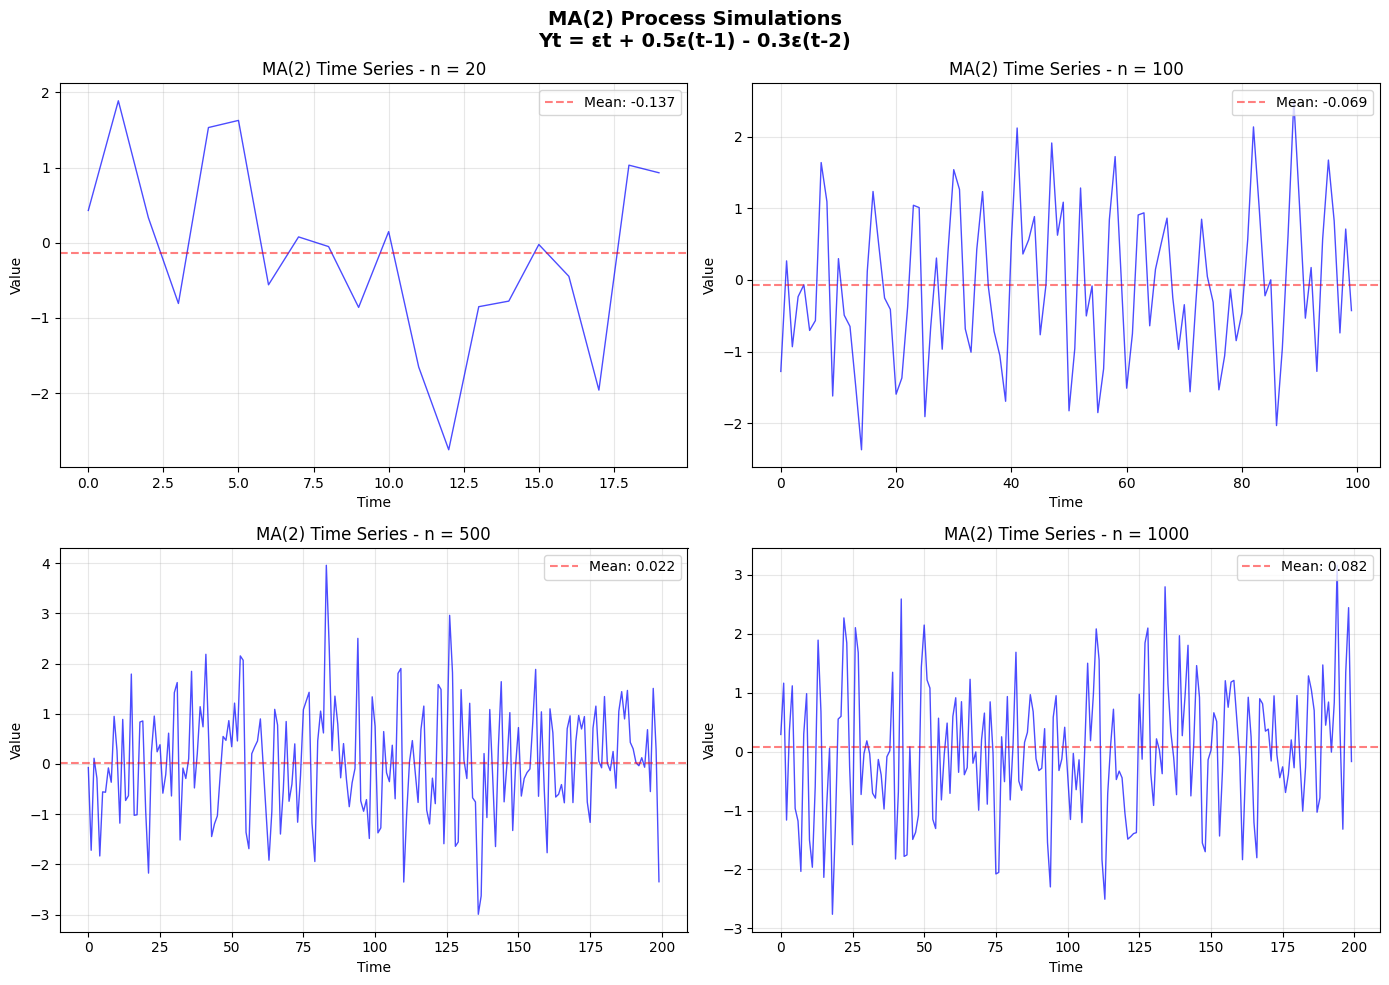

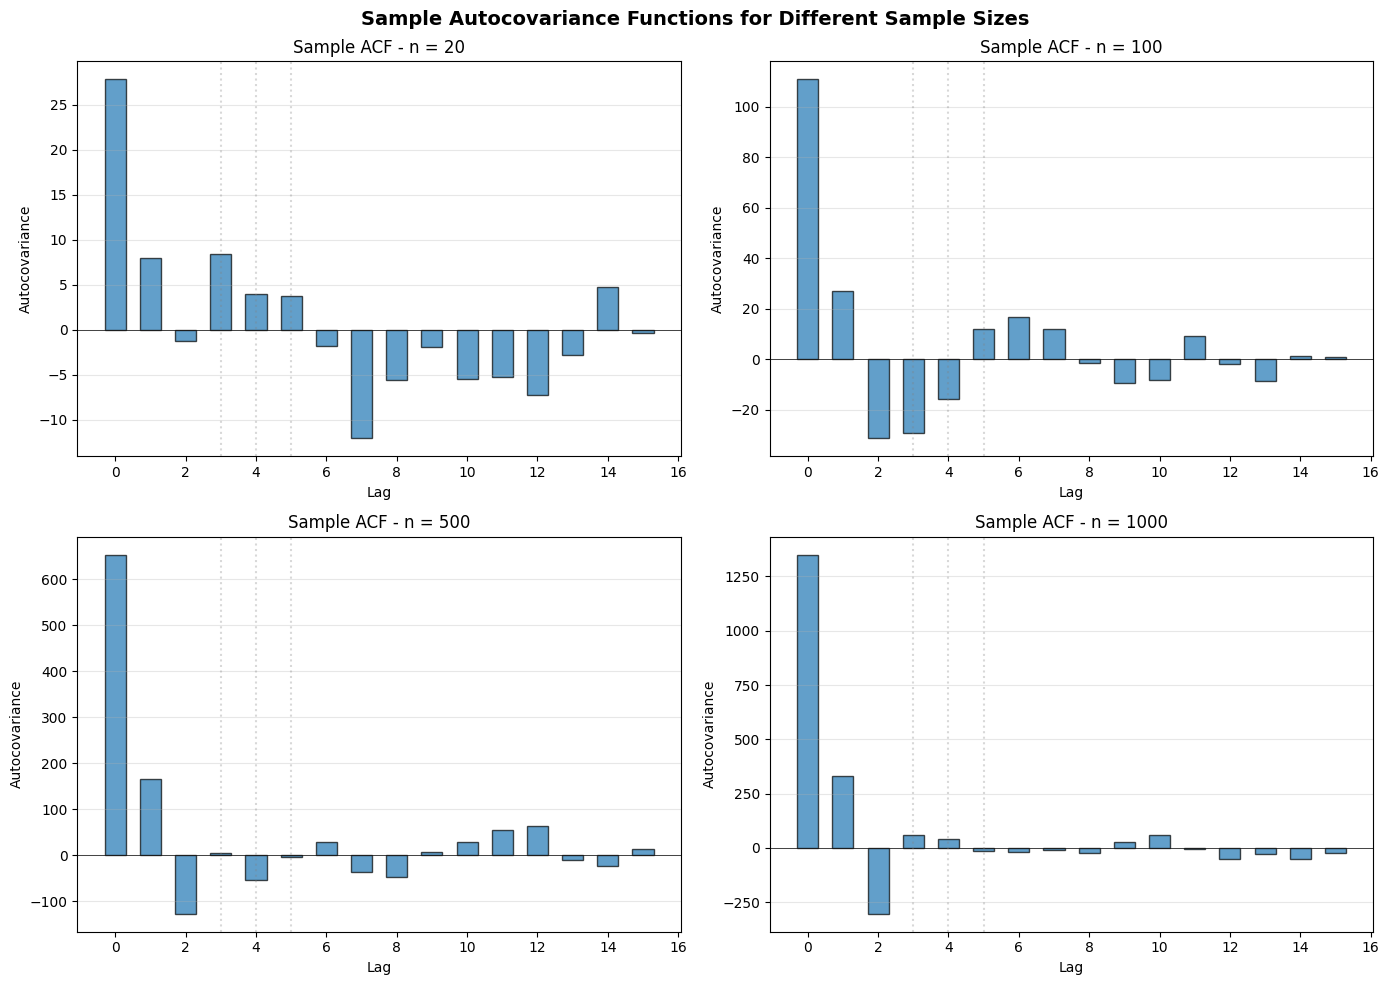

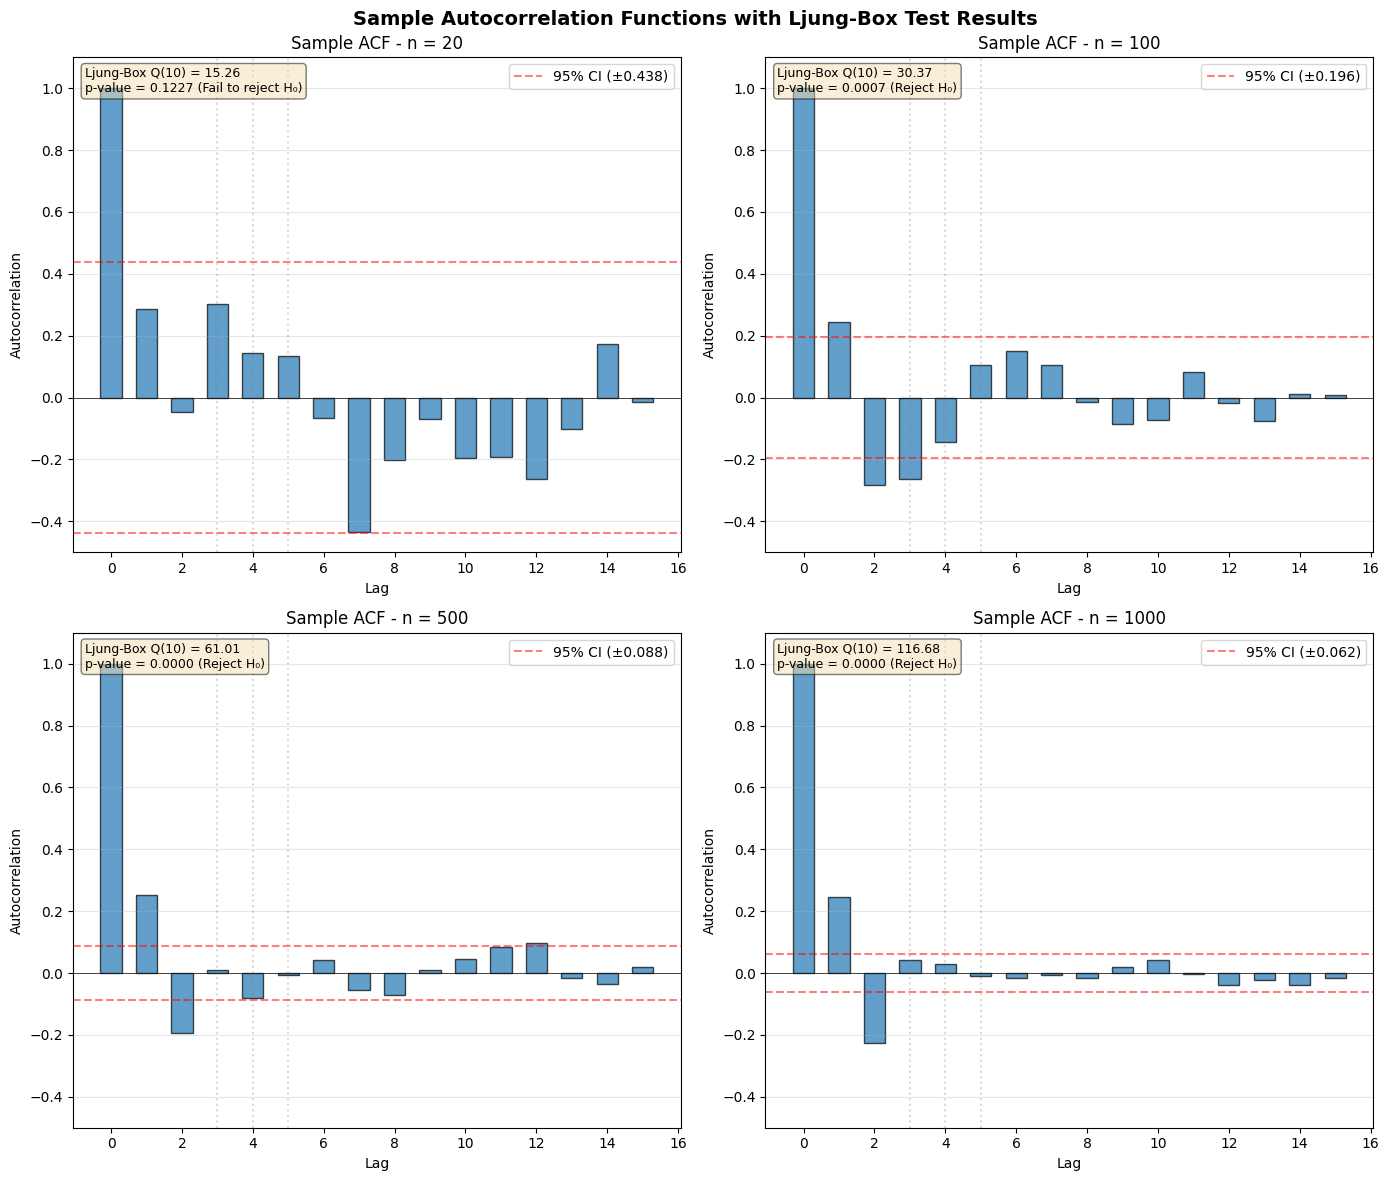

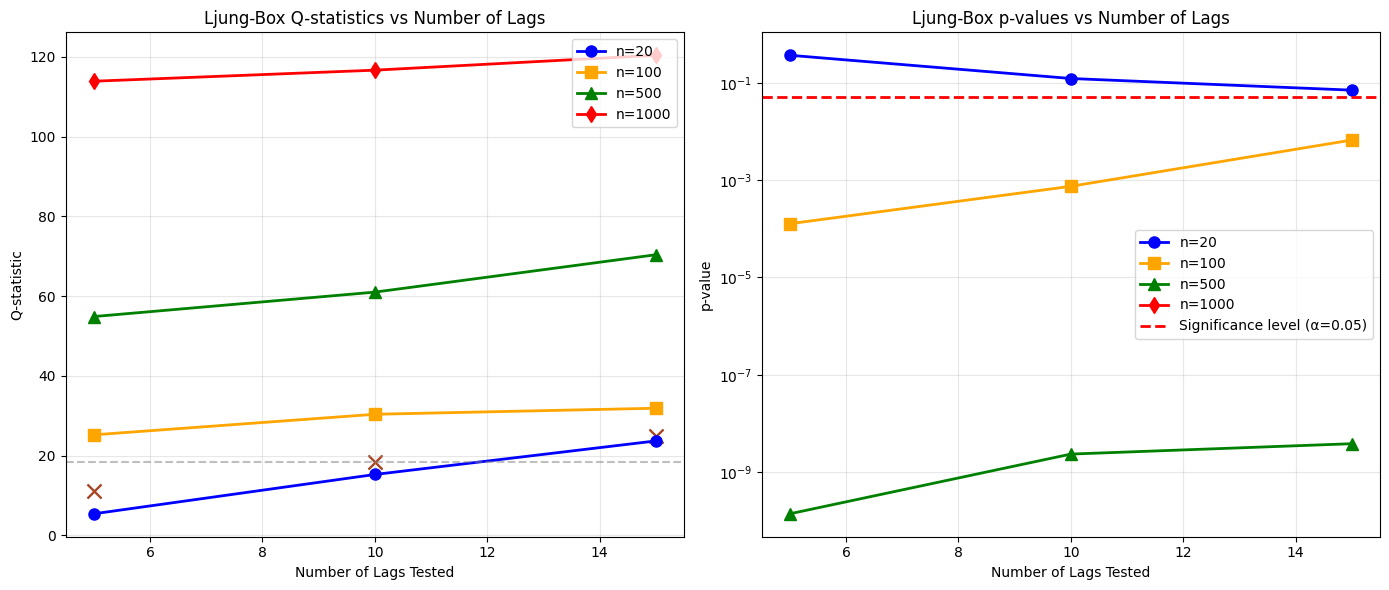


COMPREHENSIVE SUMMARY OF LJUNG-BOX TEST RESULTS

Hypothesis Test:
H₀: No autocorrelation in the residuals (white noise)
H₁: Autocorrelation present in the residuals

Significance level: α = 0.05

----------------------------------------------------------------------
Sample Size  Lags   Q-statistic  p-value      Decision            
----------------------------------------------------------------------
20           5      5.4035       0.368649     Fail to reject H₀   
20           10     15.2646      0.122708     Fail to reject H₀   
20           15     23.6839      0.070660     Fail to reject H₀   
100          5      25.2086      0.000127     REJECT H₀           
100          10     30.3666      0.000746     REJECT H₀           
100          15     31.8856      0.006673     REJECT H₀           
500          5      54.8786      0.000000     REJECT H₀           
500          10     61.0080      0.000000     REJECT H₀           
500          15     70.3836      0.000000     REJECT H₀   

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2

# Set random seed for reproducibility
np.random.seed(42)

# ============================================================================
# 1. SIMULATE MA(2) PROCESS
# ============================================================================

# MA(2) parameters
theta = [0.5, -0.3]
sigma = 1.0

# Different sample sizes to analyze
sample_sizes = [20, 100, 500, 1000]
max_lag = 15

# Store results
simulations = {}
acf_results = {}
acf_cov_results = {}

# Simulate for each sample size
for n in sample_sizes:
    # Generate white noise (error terms)
    epsilon = np.random.normal(0, sigma, n + 2)

    # Generate MA(2) process: X_t = ε_t + θ₁ε_{t-1} + θ₂ε_{t-2}
    X = np.zeros(n)
    for t in range(n):
        X[t] = epsilon[t + 2] + theta[0] * epsilon[t + 1] + theta[1] * epsilon[t]

    simulations[n] = X

    # Calculate sample autocorrelation function (ACF)
    mean_X = np.mean(X)
    acf_vals = []
    acf_vals_cov = []

    for k in range(max_lag + 1):
        if k == 0:
            acf_vals.append(1.0)
            acf_vals_cov.append(np.sum((X - mean_X) ** 2))
        else:
            # Calculate autocorrelation at lag k
            numerator = np.sum((X[k:] - mean_X) * (X[:-k] - mean_X))
            denominator = np.sum((X - mean_X) ** 2)
            acf_vals_cov.append(numerator)
            acf_vals.append(numerator / denominator)

    acf_results[n] = acf_vals
    acf_cov_results[n] = acf_vals_cov

# ============================================================================
# 2. LJUNG-BOX TEST FUNCTION
# ============================================================================

def ljung_box_test(series, lags, alpha=0.05):
    """
    Perform Ljung-Box test for autocorrelation.

    Parameters:
    -----------
    series : array-like
        Time series data
    lags : int or list
        Number of lags to test
    alpha : float
        Significance level

    Returns:
    --------
    dict : Test statistics and results
    """
    n = len(series)

    # If lags is an integer, create list from 1 to lags
    if isinstance(lags, int):
        lags_to_test = list(range(1, lags + 1))
    else:
        lags_to_test = lags

    # Calculate sample autocorrelations
    mean_series = np.mean(series)
    autocorrs = []

    for k in lags_to_test:
        if k >= n:
            continue
        numerator = np.sum((series[k:] - mean_series) * (series[:-k] - mean_series))
        denominator = np.sum((series - mean_series) ** 2)
        autocorrs.append(numerator / denominator)

    # Calculate Ljung-Box Q statistic
    Q = n * (n + 2) * np.sum([(autocorrs[i]**2) / (n - (i + 1))
                              for i in range(len(autocorrs))])

    # Degrees of freedom = number of lags
    df = len(autocorrs)

    # Calculate p-value
    p_value = 1 - chi2.cdf(Q, df)

    # Critical value
    critical_value = chi2.ppf(1 - alpha, df)

    # Decision
    reject_h0 = p_value < alpha

    return {
        'Q_statistic': Q,
        'p_value': p_value,
        'df': df,
        'critical_value': critical_value,
        'reject_h0': reject_h0,
        'autocorrelations': autocorrs,
        'lags_tested': lags_to_test
    }

# ============================================================================
# 3. PERFORM LJUNG-BOX TESTS
# ============================================================================

# Test for different lag values
test_lags = [5, 10, 15]
ljung_box_results = {}

print("=" * 70)
print("LJUNG-BOX TEST RESULTS")
print("=" * 70)

for n in sample_sizes:
    print(f"\nSample size: {n}")
    print("-" * 40)

    ljung_box_results[n] = {}

    for lag in test_lags:
        result = ljung_box_test(simulations[n], lag)
        ljung_box_results[n][lag] = result

        print(f"  Test up to lag {lag}:")
        print(f"    Q-statistic: {result['Q_statistic']:.4f}")
        print(f"    p-value: {result['p_value']:.6f}")
        print(f"    Critical value (α=0.05): {result['critical_value']:.4f}")

        if result['reject_h0']:
            print(f"    Decision: REJECT H₀ - Significant autocorrelation present")
        else:
            print(f"    Decision: Fail to reject H₀ - No significant autocorrelation")
        print()

# ============================================================================
# 4. PLOT TIME SERIES
# ============================================================================

fig1, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, n in enumerate(sample_sizes):
    axes[idx].plot(simulations[n][:200], 'b-', linewidth=1, alpha=0.7)
    axes[idx].set_title(f'MA(2) Time Series - n = {n}')
    axes[idx].set_xlabel('Time')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(True, alpha=0.3)

    # Add some statistics
    mean_val = np.mean(simulations[n])
    std_val = np.std(simulations[n])
    axes[idx].axhline(y=mean_val, color='r', linestyle='--', alpha=0.5,
                     label=f'Mean: {mean_val:.3f}')
    axes[idx].legend(loc='upper right')

plt.suptitle('MA(2) Process Simulations\nYt = εt + 0.5ε(t-1) - 0.3ε(t-2)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 5. PLOT AUTOCOVARIATION FUNCTIONS
# ============================================================================

fig2, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, n in enumerate(sample_sizes):
    lags = range(max_lag + 1)
    acf_vals_cov = acf_cov_results[n]

    # Plot ACF with bars
    axes[idx].bar(lags, acf_vals_cov, width=0.6, alpha=0.7, edgecolor='black')
    axes[idx].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

    # Mark theoretical cutoff (for MA(2), ACF should be 0 after lag 2)
    for lag in [3, 4, 5]:
        axes[idx].axvline(x=lag, color='gray', linestyle=':', alpha=0.3)

    axes[idx].set_title(f'Sample ACF - n = {n}')
    axes[idx].set_xlabel('Lag')
    axes[idx].set_ylabel('Autocovariance')
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.suptitle('Sample Autocovariance Functions for Different Sample Sizes',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 6. PLOT AUTOCORRELATION FUNCTIONS WITH LJUNG-BOX ANNOTATIONS
# ============================================================================

fig3, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, n in enumerate(sample_sizes):
    lags = range(max_lag + 1)
    acf_vals = acf_results[n]

    # Plot ACF with bars
    axes[idx].bar(lags, acf_vals, width=0.6, alpha=0.7, edgecolor='black')
    axes[idx].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

    # Add confidence intervals (95% for white noise)
    conf_level = 1.96 / np.sqrt(n)
    axes[idx].axhline(y=conf_level, color='red', linestyle='--',
                     alpha=0.5, label=f'95% CI (±{conf_level:.3f})')
    axes[idx].axhline(y=-conf_level, color='red', linestyle='--', alpha=0.5)

    # Mark theoretical cutoff (for MA(2), ACF should be 0 after lag 2)
    for lag in [3, 4, 5]:
        axes[idx].axvline(x=lag, color='gray', linestyle=':', alpha=0.3)

    # Add Ljung-Box test results annotation
    lb_result = ljung_box_results[n][10]  # Using lag 10 for annotation
    p_val_text = f"Ljung-Box Q(10) = {lb_result['Q_statistic']:.2f}\n"
    p_val_text += f"p-value = {lb_result['p_value']:.4f}"

    if lb_result['reject_h0']:
        p_val_text += " (Reject H₀)"
    else:
        p_val_text += " (Fail to reject H₀)"

    axes[idx].text(0.02, 0.98, p_val_text, transform=axes[idx].transAxes,
                  fontsize=9, verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    axes[idx].set_title(f'Sample ACF - n = {n}')
    axes[idx].set_xlabel('Lag')
    axes[idx].set_ylabel('Autocorrelation')
    axes[idx].set_ylim([-0.5, 1.1])
    axes[idx].legend(loc='upper right')
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.suptitle('Sample Autocorrelation Functions with Ljung-Box Test Results',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 7. PLOT LJUNG-BOX TEST STATISTICS
# ============================================================================

fig4, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot Q-statistics for different sample sizes and lags
colors = ['blue', 'orange', 'green', 'red']
markers = ['o', 's', '^', 'd']

for idx, n in enumerate(sample_sizes):
    q_stats = []
    for lag in test_lags:
        q_stats.append(ljung_box_results[n][lag]['Q_statistic'])

    ax1.plot(test_lags, q_stats, marker=markers[idx],
             color=colors[idx], linewidth=2, markersize=8,
             label=f'n={n}')

    # Add critical value lines for each lag
    for lag_idx, lag in enumerate(test_lags):
        crit_val = ljung_box_results[n][lag]['critical_value']
        ax1.scatter(lag, crit_val, color=colors[idx],
                   marker='x', s=100, alpha=0.5)

ax1.set_xlabel('Number of Lags Tested')
ax1.set_ylabel('Q-statistic')
ax1.set_title('Ljung-Box Q-statistics vs Number of Lags')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axhline(y=chi2.ppf(0.95, df=10), color='gray', linestyle='--',
           alpha=0.5, label='χ²(10) crit (α=0.05)')

# Plot p-values
for idx, n in enumerate(sample_sizes):
    p_vals = []
    for lag in test_lags:
        p_vals.append(ljung_box_results[n][lag]['p_value'])

    ax2.plot(test_lags, p_vals, marker=markers[idx],
             color=colors[idx], linewidth=2, markersize=8,
             label=f'n={n}')

ax2.axhline(y=0.05, color='red', linestyle='--', linewidth=2,
           label='Significance level (α=0.05)')
ax2.set_xlabel('Number of Lags Tested')
ax2.set_ylabel('p-value')
ax2.set_title('Ljung-Box p-values vs Number of Lags')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')  # Log scale for better visualization of small p-values

plt.tight_layout()
plt.show()

# ============================================================================
# 8. COMPREHENSIVE SUMMARY TABLE
# ============================================================================

print("\n" + "=" * 70)
print("COMPREHENSIVE SUMMARY OF LJUNG-BOX TEST RESULTS")
print("=" * 70)
print("\nHypothesis Test:")
print("H₀: No autocorrelation in the residuals (white noise)")
print("H₁: Autocorrelation present in the residuals")
print("\nSignificance level: α = 0.05")
print("\n" + "-" * 70)

# Create a formatted table
print(f"{'Sample Size':<12} {'Lags':<6} {'Q-statistic':<12} {'p-value':<12} {'Decision':<20}")
print("-" * 70)

for n in sample_sizes:
    for lag in test_lags:
        result = ljung_box_results[n][lag]
        decision = "REJECT H₀" if result['reject_h0'] else "Fail to reject H₀"
        print(f"{n:<12} {lag:<6} {result['Q_statistic']:<12.4f} "
              f"{result['p_value']:<12.6f} {decision:<20}")

print("\n" + "=" * 70)
print("INTERPRETATION:")
print("=" * 70)
print("\nFor MA(2) process with θ = [0.5, -0.3]:")
print("- We expect significant autocorrelation at lags 1 and 2")
print("- We expect no significant autocorrelation beyond lag 2")
print("\nExpected Results:")
print("1. Small sample sizes (n=20): Test may have low power")
print("2. Larger sample sizes: Should reliably detect autocorrelation")
print("3. As n increases, p-values should become very small")
print("\nThe Ljung-Box test checks if any autocorrelation exists")
print("up to the specified lag, not just at individual lags.")

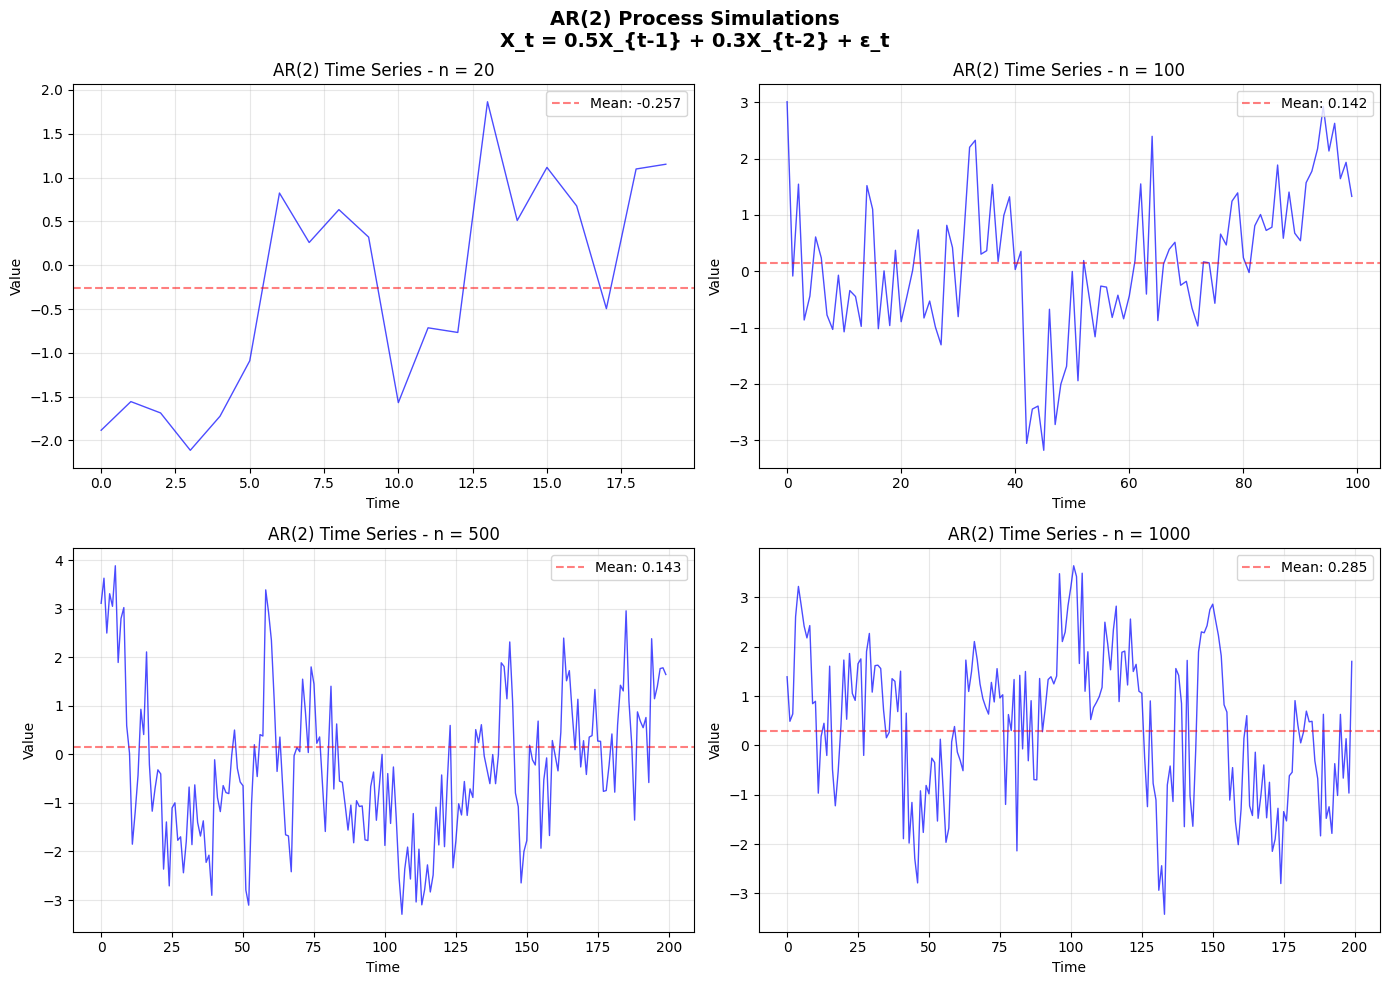

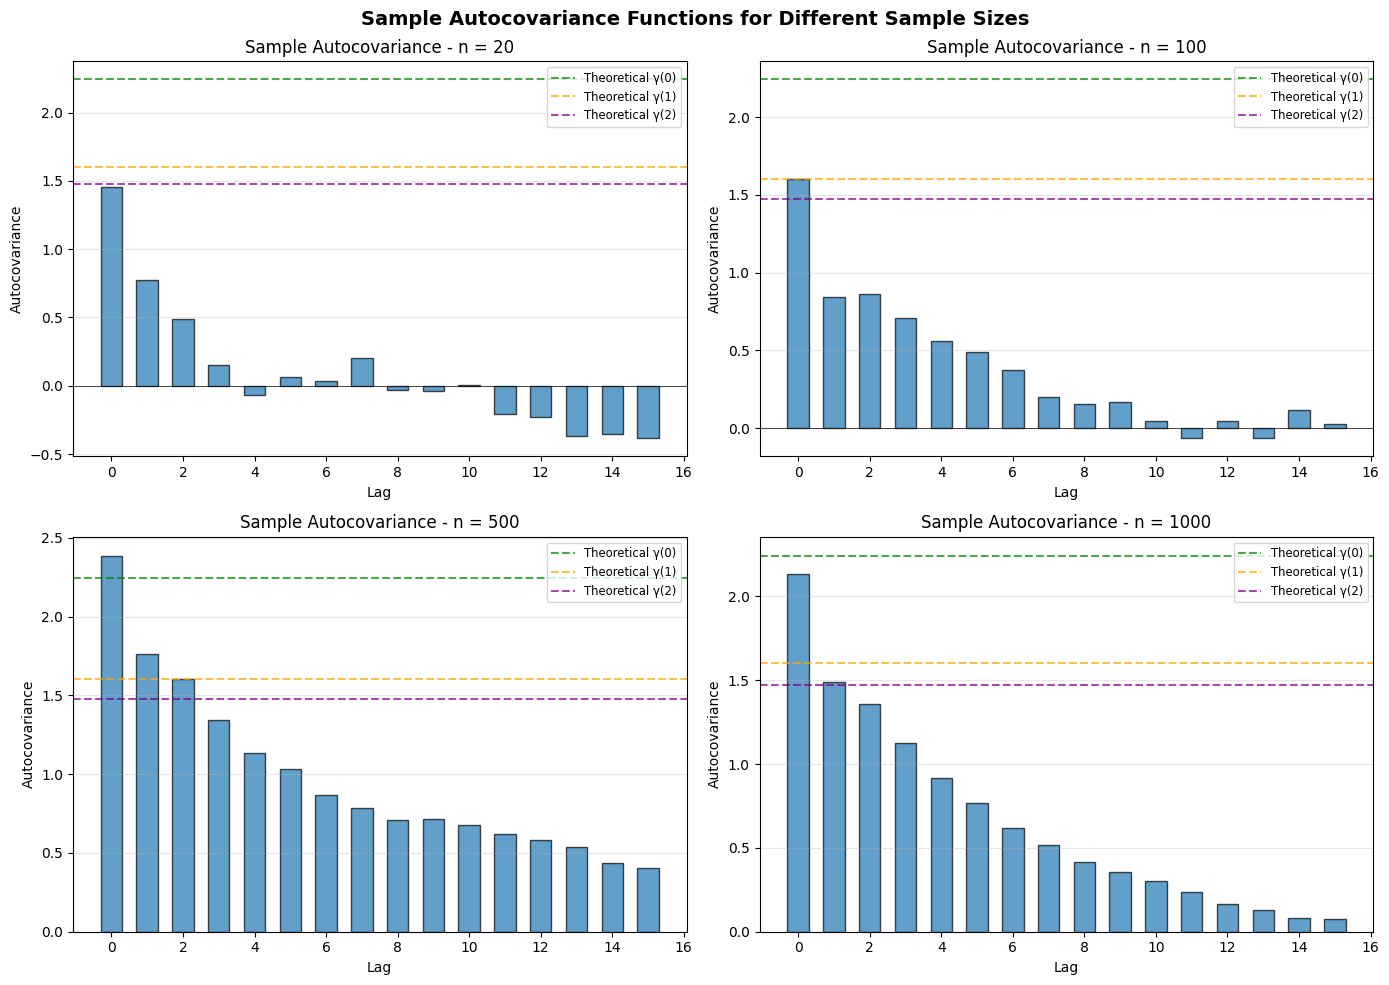

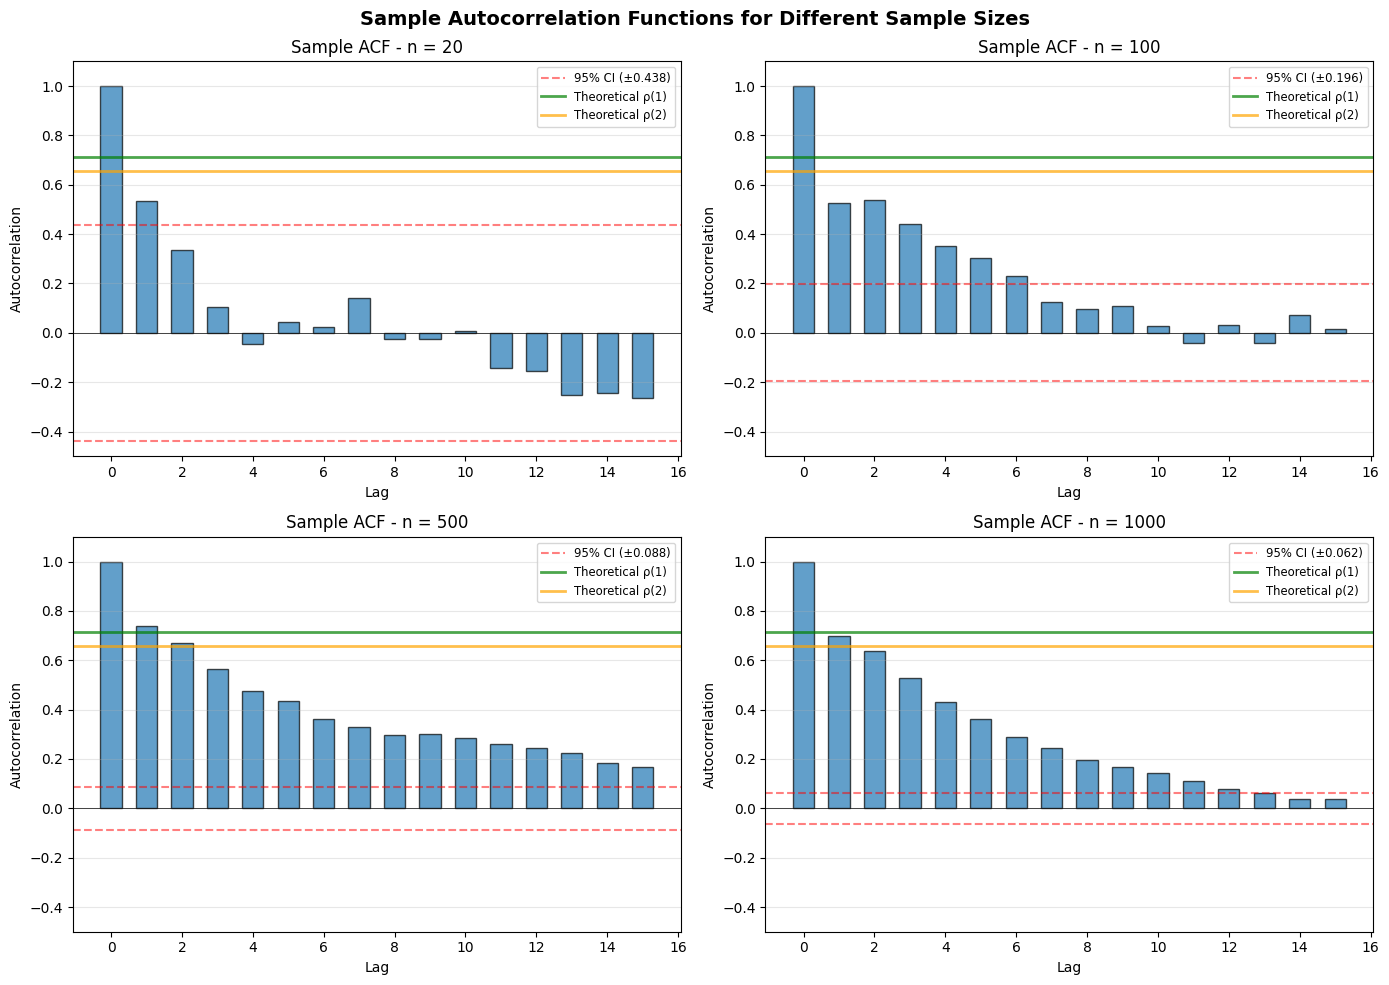

LJUNG-BOX TEST FOR AUTOCORRELATION
Null Hypothesis: No autocorrelation up to lag k
Alternative Hypothesis: Autocorrelation exists at some lag ≤ k

Ljung-Box Test Statistics and P-values:
----------------------------------------------------------------------
Sample Size  Lag k    Q-statistic     P-value      Reject H0 (α=0.05)  
----------------------------------------------------------------------
20           1        6.5635          0.0104       Yes                 
20           2        9.2878          0.0096       Yes                 
20           5        9.6724          0.0851       No                  
20           10       10.4176         0.4046       No                  
100          1        28.4141         0.0000       Yes                 
100          2        58.7191         0.0000       Yes                 
100          5        102.2260        0.0000       Yes                 
100          10       112.1330        0.0000       Yes                 
500          1        2

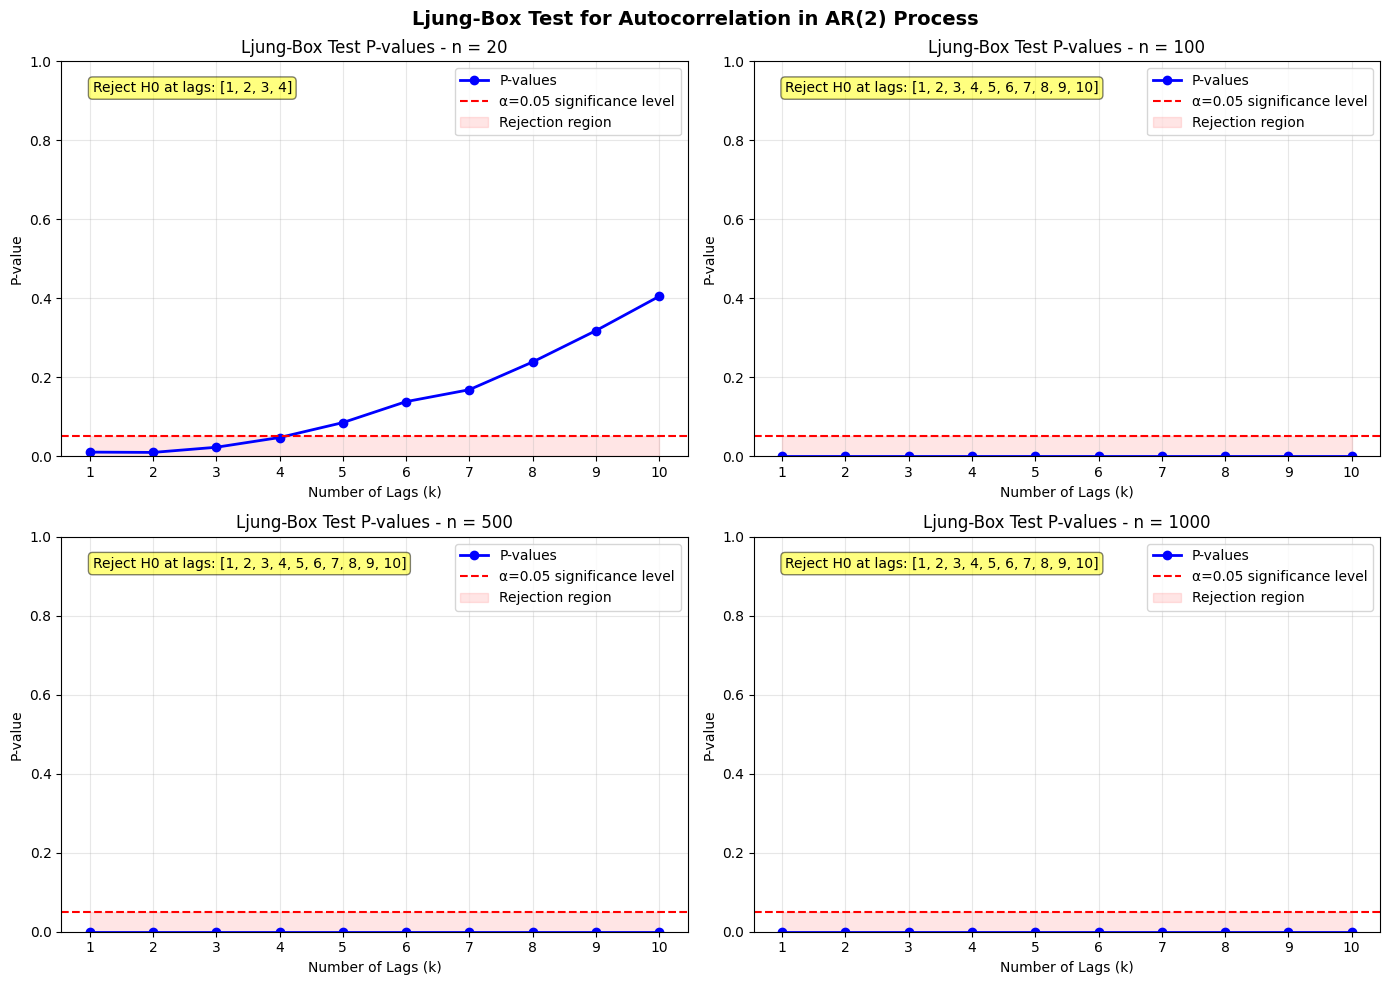

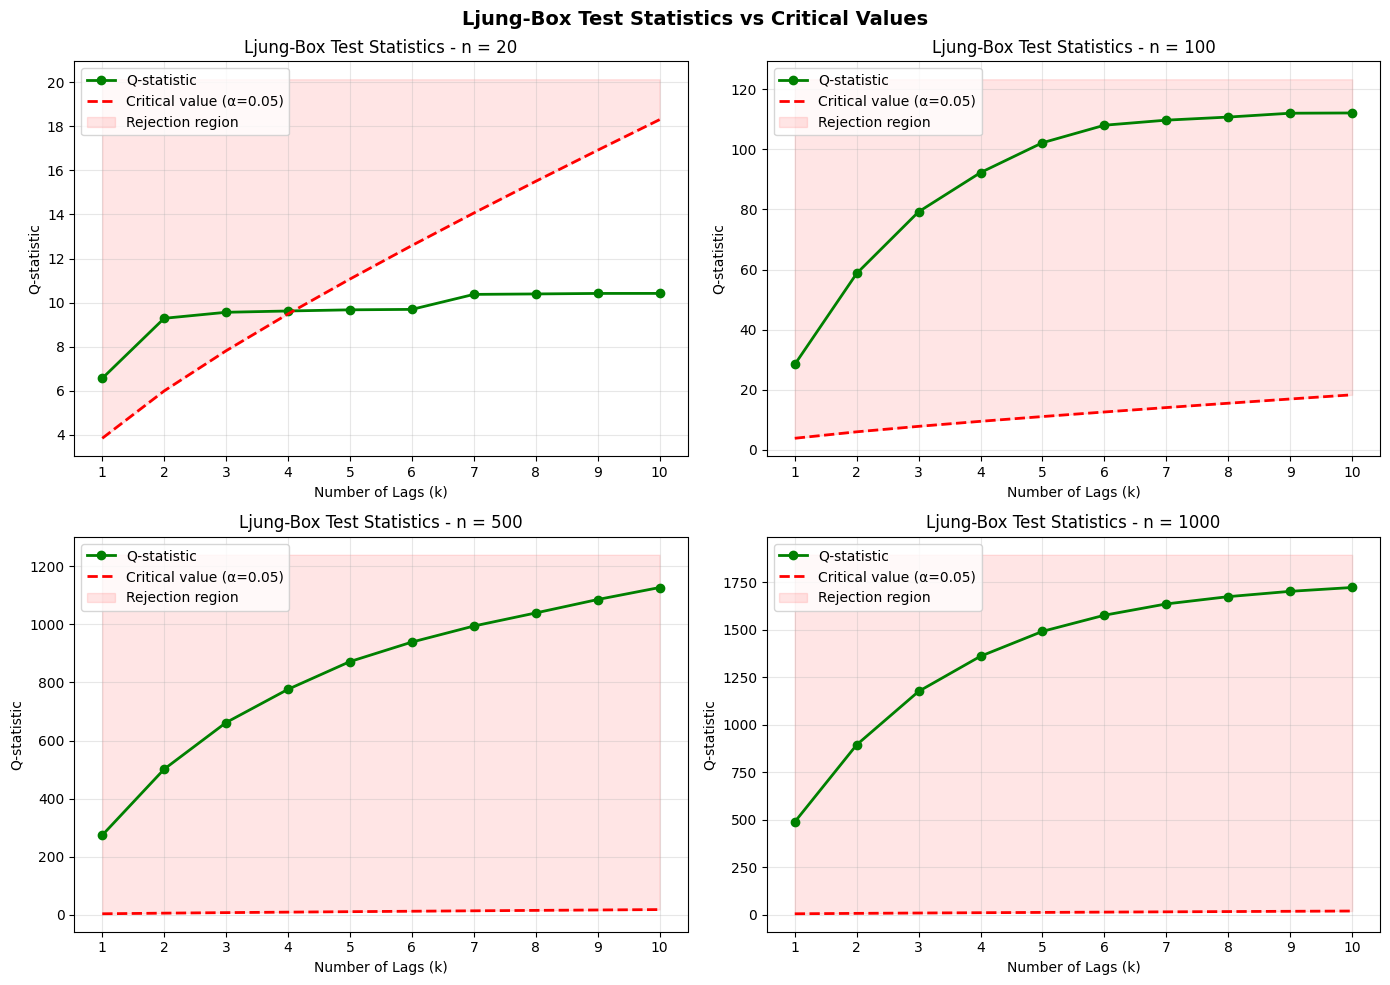

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Set random seed for reproducibility
np.random.seed(42)

# ============================================================================
# 1. SIMULATE AR(2) PROCESS
# ============================================================================

# AR(2) parameters
phi = [0.5, 0.3]  # φ1 = 0.5, φ2 = 0.3
sigma = 1.0

# Different sample sizes to analyze
sample_sizes = [20, 100, 500, 1000]
max_lag = 15

# Store results
simulations = {}
acf_results = {}
acf_cov_results = {}
ljung_box_results = {}

# Simulate for each sample size
for n in sample_sizes:
    # Generate white noise (error terms)
    epsilon = np.random.normal(0, sigma, n + 100)  # Extra for burn-in

    # Generate AR(2) process: X_t = φ1*X_{t-1} + φ2*X_{t-2} + ε_t
    X = np.zeros(n + 100)
    X[0] = epsilon[0]
    X[1] = epsilon[1]

    # Generate the process
    for t in range(2, n + 100):
        X[t] = phi[0] * X[t-1] + phi[1] * X[t-2] + epsilon[t]

    # Discard first 100 values as burn-in to remove initialization effects
    X = X[100:]

    simulations[n] = X

    # Calculate sample autocorrelation function (ACF)
    mean_X = np.mean(X)
    acf_vals = []
    acf_vals_cov = []

    for k in range(max_lag + 1):
        if k == 0:
            acf_vals.append(1.0)
            acf_vals_cov.append(np.sum((X - mean_X) ** 2) / n)
        else:
            # Calculate autocovariance at lag k
            numerator = np.sum((X[k:] - mean_X) * (X[:-k] - mean_X)) / n
            denominator = np.sum((X - mean_X) ** 2) / n
            acf_vals_cov.append(numerator)
            acf_vals.append(numerator / denominator)

    acf_results[n] = acf_vals
    acf_cov_results[n] = acf_vals_cov

    # Calculate Ljung-Box test statistics for multiple lags
    ljung_box_stats = []
    ljung_box_pvalues = []

    # Test for lags 1 through 10
    for k in range(1, 11):
        # Ljung-Box test statistic: Q = n(n+2) * Σ(ρ_k²/(n-k)) from k=1 to m
        Q = n * (n + 2) * sum([(acf_vals[i] ** 2) / (n - i) for i in range(1, k + 1)])
        # Degrees of freedom = k (number of lags tested)
        df = k
        # p-value from chi-square distribution
        p_value = 1 - stats.chi2.cdf(Q, df)

        ljung_box_stats.append(Q)
        ljung_box_pvalues.append(p_value)

    ljung_box_results[n] = {
        'stats': ljung_box_stats,
        'pvalues': ljung_box_pvalues
    }

# ============================================================================
# 2. PLOT TIME SERIES
# ============================================================================

fig1, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, n in enumerate(sample_sizes):
    axes[idx].plot(simulations[n][:200], 'b-', linewidth=1, alpha=0.7)
    axes[idx].set_title(f'AR(2) Time Series - n = {n}')
    axes[idx].set_xlabel('Time')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(True, alpha=0.3)

    # Add some statistics
    mean_val = np.mean(simulations[n])
    std_val = np.std(simulations[n])
    axes[idx].axhline(y=mean_val, color='r', linestyle='--', alpha=0.5,
                     label=f'Mean: {mean_val:.3f}')
    axes[idx].legend(loc='upper right')

plt.suptitle('AR(2) Process Simulations\nX_t = 0.5X_{t-1} + 0.3X_{t-2} + ε_t',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 3. PLOT AUTOCOVARIANCE FUNCTIONS
# ============================================================================

fig2, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, n in enumerate(sample_sizes):
    lags = range(max_lag + 1)
    acf_vals_cov = acf_cov_results[n]

    # Plot ACF with bars
    axes[idx].bar(lags, acf_vals_cov, width=0.6, alpha=0.7, edgecolor='black')
    axes[idx].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

    # Calculate theoretical autocovariance for AR(2)
    rho1 = phi[0] / (1 - phi[1])
    rho2 = phi[0] * rho1 + phi[1]

    # Theoretical variance
    gamma0 = sigma**2 / (1 - phi[0] * rho1 - phi[1] * rho2)

    # Theoretical autocovariances
    gamma1 = phi[0] * gamma0 + phi[1] * rho1 * gamma0
    gamma2 = phi[0] * gamma1 + phi[1] * gamma0

    # Plot theoretical values as horizontal lines for comparison
    axes[idx].axhline(y=gamma0, color='green', linestyle='--', alpha=0.7,
                     label='Theoretical γ(0)')
    axes[idx].axhline(y=gamma1, color='orange', linestyle='--', alpha=0.7,
                     label='Theoretical γ(1)', linewidth=1.5)
    axes[idx].axhline(y=gamma2, color='purple', linestyle='--', alpha=0.7,
                     label='Theoretical γ(2)', linewidth=1.5)

    axes[idx].set_title(f'Sample Autocovariance - n = {n}')
    axes[idx].set_xlabel('Lag')
    axes[idx].set_ylabel('Autocovariance')
    axes[idx].legend(loc='upper right', fontsize='small')
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.suptitle('Sample Autocovariance Functions for Different Sample Sizes',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 4. PLOT AUTOCORRELATION FUNCTIONS
# ============================================================================

fig3, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, n in enumerate(sample_sizes):
    lags = range(max_lag + 1)
    acf_vals = acf_results[n]

    # Plot ACF with bars
    axes[idx].bar(lags, acf_vals, width=0.6, alpha=0.7, edgecolor='black')
    axes[idx].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

    # Add confidence intervals (95% for white noise)
    conf_level = 1.96 / np.sqrt(n)
    axes[idx].axhline(y=conf_level, color='red', linestyle='--',
                     alpha=0.5, label=f'95% CI (±{conf_level:.3f})')
    axes[idx].axhline(y=-conf_level, color='red', linestyle='--', alpha=0.5)

    # Calculate theoretical autocorrelations for AR(2)
    rho1 = phi[0] / (1 - phi[1])
    rho2 = phi[0] * rho1 + phi[1]

    # Plot theoretical autocorrelations
    axes[idx].axhline(y=rho1, color='green', linestyle='-', alpha=0.7,
                     label='Theoretical ρ(1)', linewidth=2)
    axes[idx].axhline(y=rho2, color='orange', linestyle='-', alpha=0.7,
                     label='Theoretical ρ(2)', linewidth=2)

    axes[idx].set_title(f'Sample ACF - n = {n}')
    axes[idx].set_xlabel('Lag')
    axes[idx].set_ylabel('Autocorrelation')
    axes[idx].set_ylim([-0.5, 1.1])
    axes[idx].legend(loc='upper right', fontsize='small')
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.suptitle('Sample Autocorrelation Functions for Different Sample Sizes',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 5. LJUNG-BOX TEST RESULTS
# ============================================================================

print("=" * 70)
print("LJUNG-BOX TEST FOR AUTOCORRELATION")
print("=" * 70)
print("Null Hypothesis: No autocorrelation up to lag k")
print("Alternative Hypothesis: Autocorrelation exists at some lag ≤ k")
print("=" * 70)

# Print Ljung-Box test results table
print("\nLjung-Box Test Statistics and P-values:")
print("-" * 70)
print(f"{'Sample Size':<12} {'Lag k':<8} {'Q-statistic':<15} {'P-value':<12} {'Reject H0 (α=0.05)':<20}")
print("-" * 70)

for n in sample_sizes:
    stats_vals = ljung_box_results[n]['stats']
    pvalues = ljung_box_results[n]['pvalues']

    for k in range(1, 11):
        Q = stats_vals[k-1]
        p_val = pvalues[k-1]
        reject = "Yes" if p_val < 0.05 else "No"

        if k in [1, 2, 5, 10]:  # Display only selected lags for clarity
            print(f"{n:<12} {k:<8} {Q:<15.4f} {p_val:<12.4f} {reject:<20}")

# ============================================================================
# 6. PLOT LJUNG-BOX TEST RESULTS
# ============================================================================

fig4, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, n in enumerate(sample_sizes):
    lags = range(1, 11)  # Lags 1 through 10
    pvalues = ljung_box_results[n]['pvalues']

    # Plot p-values
    axes[idx].plot(lags, pvalues, 'bo-', linewidth=2, markersize=6,
                  label='P-values')

    # Add horizontal line at significance level α=0.05
    axes[idx].axhline(y=0.05, color='red', linestyle='--', linewidth=1.5,
                     label='α=0.05 significance level')

    # Shade the rejection region
    axes[idx].fill_between(lags, 0, 0.05, color='red', alpha=0.1,
                          label='Rejection region')

    # Add text for interpretation
    significant_lags = [lag for lag, p in enumerate(pvalues, 1) if p < 0.05]
    if significant_lags:
        axes[idx].text(0.05, 0.95, f'Reject H0 at lags: {significant_lags}',
                      transform=axes[idx].transAxes, verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))
    else:
        axes[idx].text(0.05, 0.95, 'Fail to reject H0',
                      transform=axes[idx].transAxes, verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

    axes[idx].set_title(f'Ljung-Box Test P-values - n = {n}')
    axes[idx].set_xlabel('Number of Lags (k)')
    axes[idx].set_ylabel('P-value')
    axes[idx].set_ylim([0, 1])
    axes[idx].set_xticks(lags)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(loc='upper right')

plt.suptitle('Ljung-Box Test for Autocorrelation in AR(2) Process',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 7. PLOT LJUNG-BOX TEST STATISTICS
# ============================================================================

fig5, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, n in enumerate(sample_sizes):
    lags = range(1, 11)  # Lags 1 through 10
    stats_vals = ljung_box_results[n]['stats']

    # Plot test statistics
    axes[idx].plot(lags, stats_vals, 'go-', linewidth=2, markersize=6,
                  label='Q-statistic')

    # Add critical values from chi-square distribution (α=0.05)
    critical_values = [stats.chi2.ppf(0.95, df=k) for k in lags]
    axes[idx].plot(lags, critical_values, 'r--', linewidth=2,
                  label='Critical value (α=0.05)')

    # Shade the rejection region
    axes[idx].fill_between(lags, critical_values,
                          max(critical_values + stats_vals) * 1.1,
                          color='red', alpha=0.1, label='Rejection region')

    axes[idx].set_title(f'Ljung-Box Test Statistics - n = {n}')
    axes[idx].set_xlabel('Number of Lags (k)')
    axes[idx].set_ylabel('Q-statistic')
    axes[idx].set_xticks(lags)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(loc='upper left')

plt.suptitle('Ljung-Box Test Statistics vs Critical Values',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

LJUNG-BOX TEST RESULTS FOR MA(2) PROCESS
MA(2) Parameters: θ₁ = 0.72, θ₂ = -0.12

Sample size: 30
----------------------------------------
  Test up to lag 5:
    Q-statistic: 10.0700
    p-value: 0.073276
    Critical value (α=0.05): 11.0705
    Decision: Fail to reject H₀ - No significant autocorrelation

  Test up to lag 10:
    Q-statistic: 17.1570
    p-value: 0.070962
    Critical value (α=0.05): 18.3070
    Decision: Fail to reject H₀ - No significant autocorrelation

  Test up to lag 15:
    Q-statistic: 22.1981
    p-value: 0.102713
    Critical value (α=0.05): 24.9958
    Decision: Fail to reject H₀ - No significant autocorrelation


Sample size: 100
----------------------------------------
  Test up to lag 5:
    Q-statistic: 28.0397
    p-value: 0.000036
    Critical value (α=0.05): 11.0705
    Decision: REJECT H₀ - Significant autocorrelation present

  Test up to lag 10:
    Q-statistic: 40.3745
    p-value: 0.000015
    Critical value (α=0.05): 18.3070
    Decision: REJE

/tmp/ipython-input-2941270441.py:214: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-2941270441.py:214: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-2941270441.py:215: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.savefig('MA2_timeseries.png', dpi=150, bbox_inches='tight')
/tmp/ipython-input-2941270441.py:215: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.savefig('MA2_timeseries.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sa

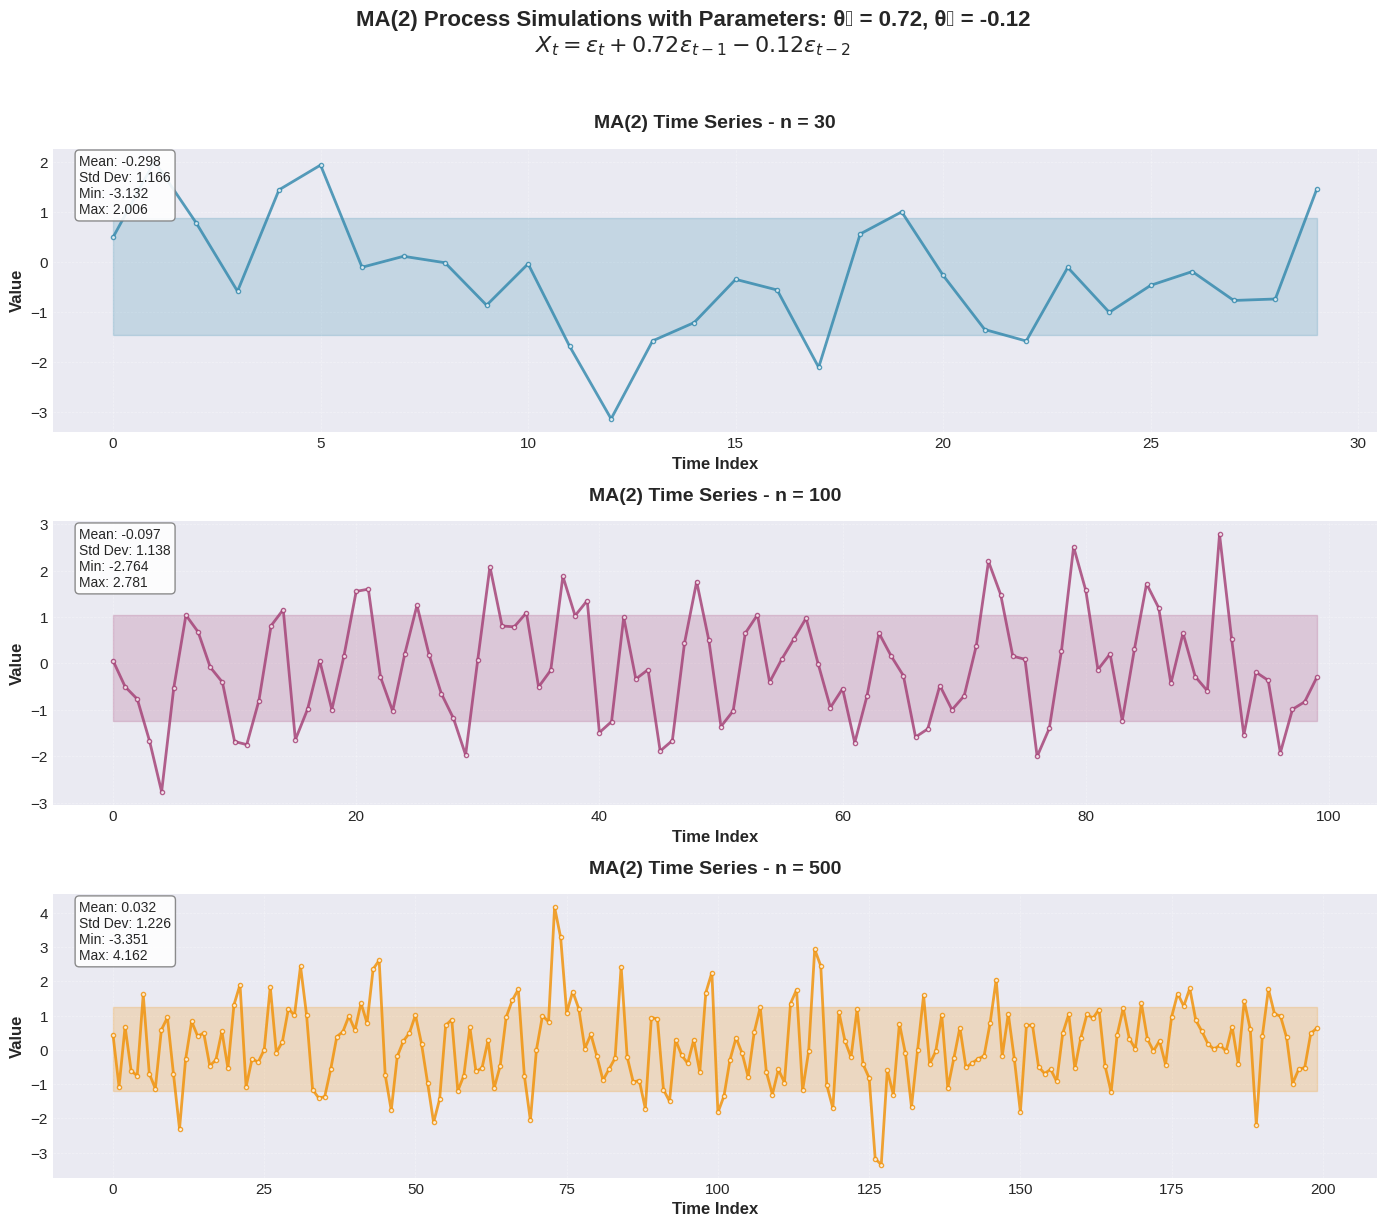

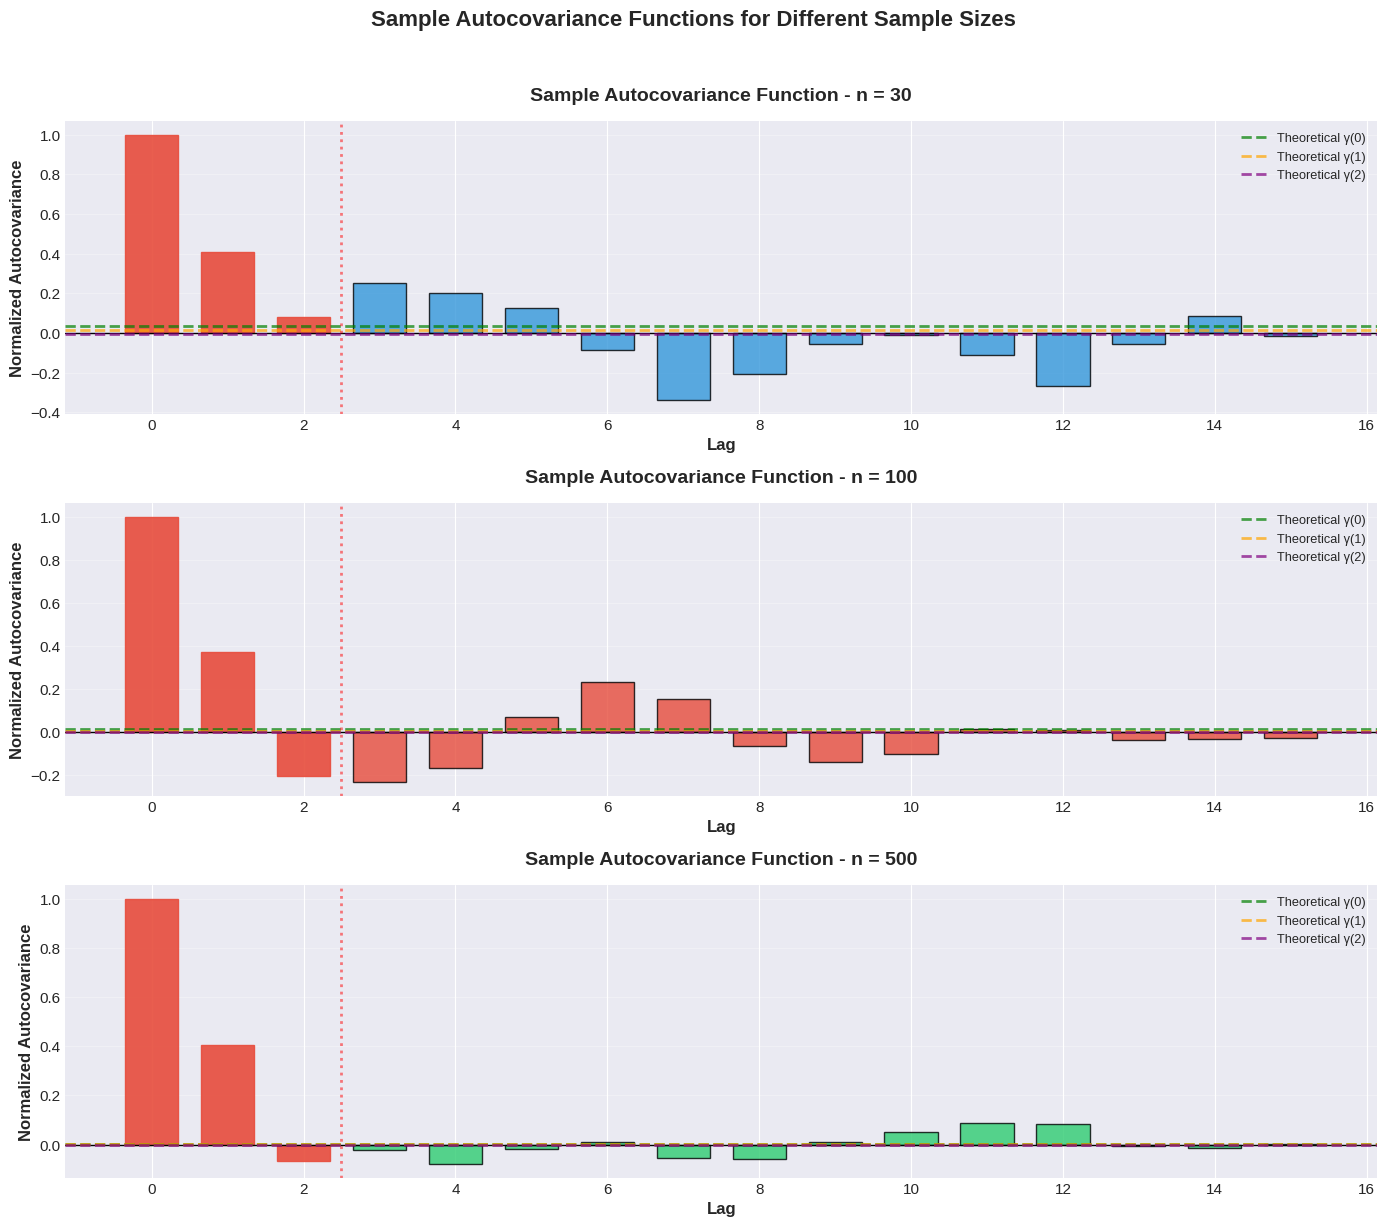

/tmp/ipython-input-2941270441.py:365: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-2941270441.py:366: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Liberation Sans.
  plt.savefig('MA2_autocorrelation.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


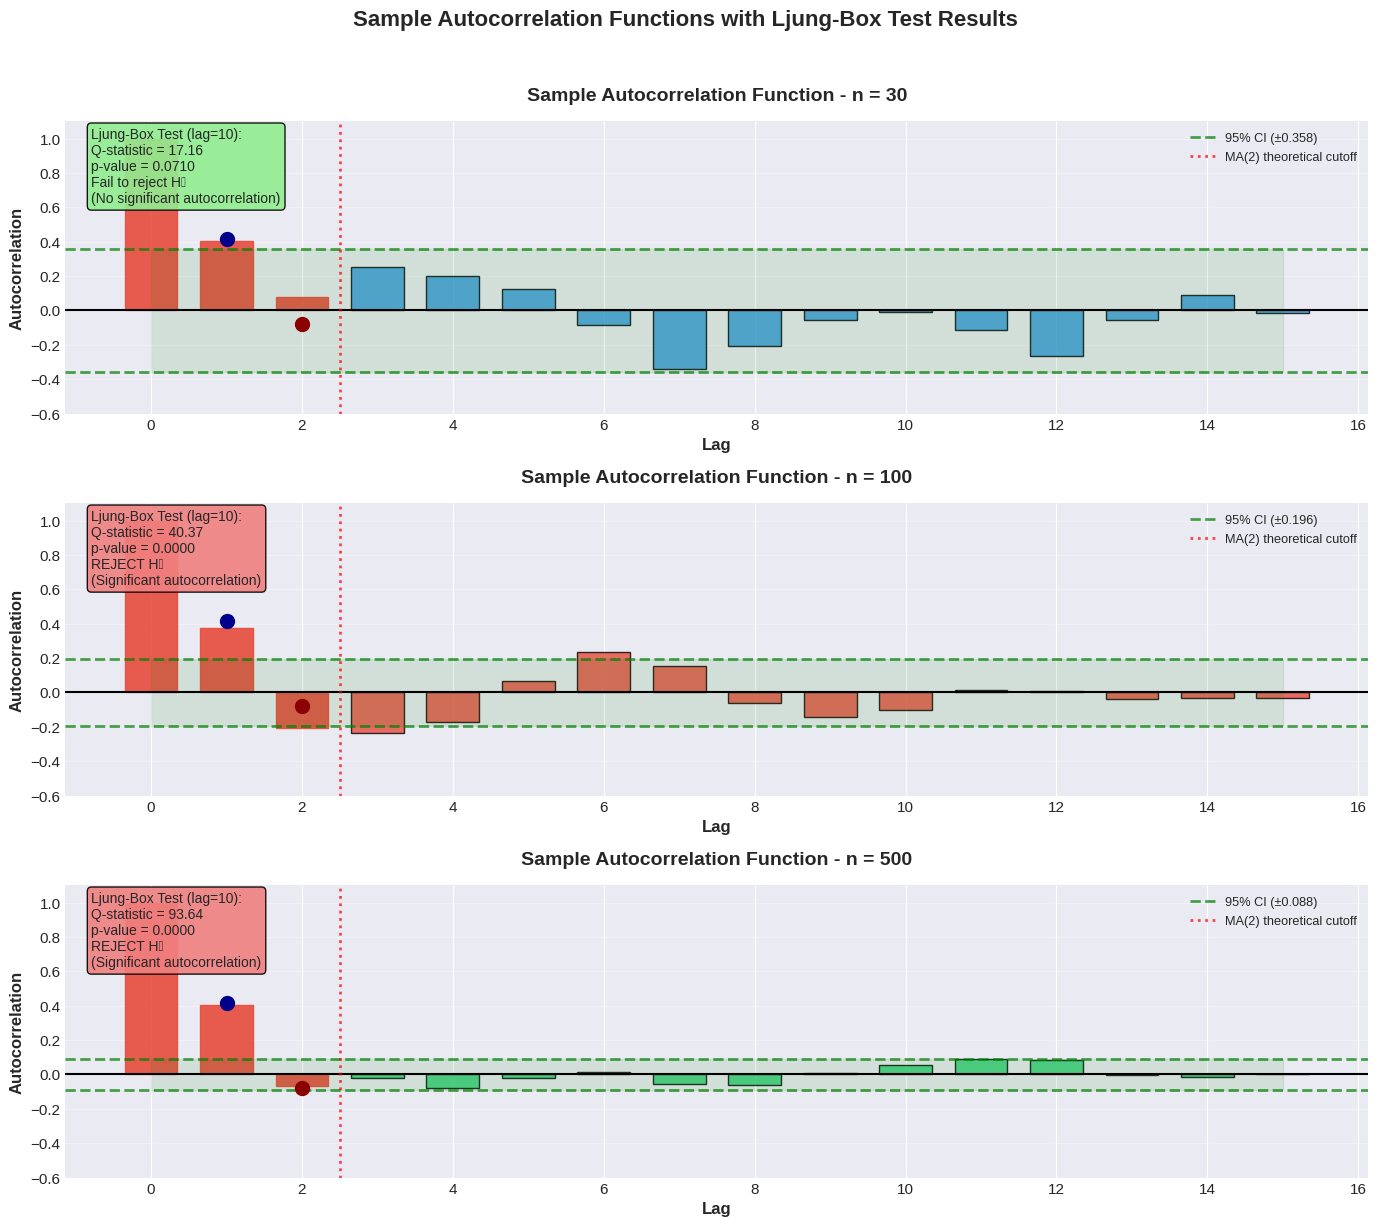

/tmp/ipython-input-2941270441.py:463: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-2941270441.py:463: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-2941270441.py:463: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-2941270441.py:464: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Liberation Sans.
  plt.savefig('MA2_ljung_box.png', dpi=150, bbox_inches='tight')
/tmp/ipython-input-2941270441.py:464: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.savefig('MA2_ljung_box.png', dpi=150, bbox_inches='tight')
/tmp/ipython-input-2941270441.py:464: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.savefig('MA2_ljung_box.png', dpi=150, bbox_inches='tight')


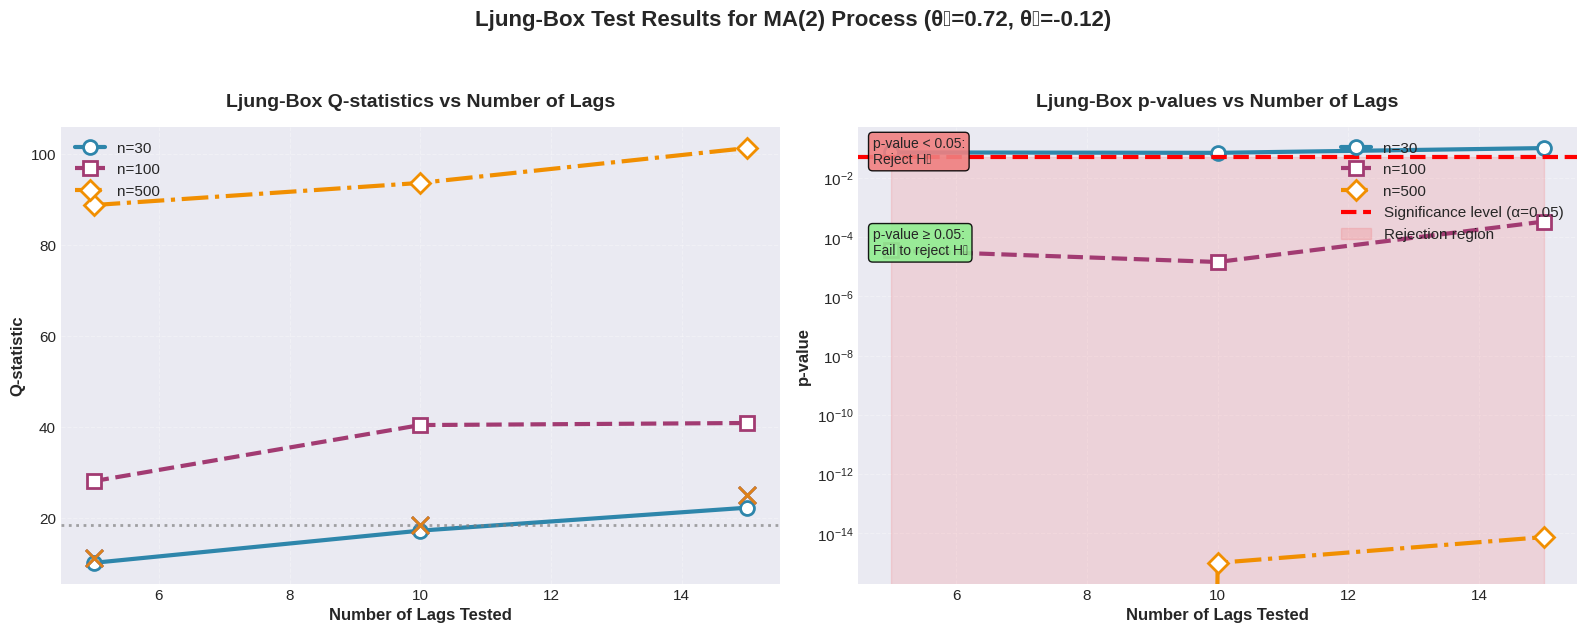


COMPREHENSIVE SUMMARY OF LJUNG-BOX TEST RESULTS

MA(2) Process Parameters: θ₁ = 0.72, θ₂ = -0.12
Process: X_t = ε_t + θ₁ε_{t-1} + θ₂ε_{t-2}

Hypothesis Test:
H₀: No autocorrelation in the residuals (white noise)
H₁: Autocorrelation present in the residuals

Significance level: α = 0.05

------------------------------------------------------------------------------------------
Sample Size  Lags     Q-statistic    p-value        Critical Value   Decision                 
------------------------------------------------------------------------------------------
30           5        10.0700        0.073276       11.0705          Fail to reject H₀        
30           10       17.1570        0.070962       18.3070          Fail to reject H₀        
30           15       22.1981        0.102713       24.9958          Fail to reject H₀        
100          5        28.0397        0.000036       11.0705          REJECT H₀                
100          10       40.3745        0.000015       18

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2

# Set style for better looking charts
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Set random seed for reproducibility
np.random.seed(42)

# ============================================================================
# 1. SIMULATE MA(2) PROCESS WITH UPDATED PARAMETERS
# ============================================================================

# MA(2) parameters - CHANGED TO 0.72 AND -0.12
theta = [0.72, -0.12]  # CHANGED
sigma = 1.0

# Different sample sizes to analyze - CHANGED TO 30, 100, 500
sample_sizes = [30, 100, 500]  # CHANGED
max_lag = 15

# Store results
simulations = {}
acf_results = {}
acf_cov_results = {}

# Color palette for better visualization
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
bar_colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

# Simulate for each sample size
for n in sample_sizes:
    # Generate white noise (error terms)
    epsilon = np.random.normal(0, sigma, n + 2)

    # Generate MA(2) process: X_t = ε_t + θ₁ε_{t-1} + θ₂ε_{t-2}
    X = np.zeros(n)
    for t in range(n):
        X[t] = epsilon[t + 2] + theta[0] * epsilon[t + 1] + theta[1] * epsilon[t]

    simulations[n] = X

    # Calculate sample autocorrelation function (ACF)
    mean_X = np.mean(X)
    acf_vals = []
    acf_vals_cov = []

    for k in range(max_lag + 1):
        if k == 0:
            acf_vals.append(1.0)
            acf_vals_cov.append(np.sum((X - mean_X) ** 2))
        else:
            # Calculate autocorrelation at lag k
            numerator = np.sum((X[k:] - mean_X) * (X[:-k] - mean_X))
            denominator = np.sum((X - mean_X) ** 2)
            acf_vals_cov.append(numerator)
            acf_vals.append(numerator / denominator)

    acf_results[n] = acf_vals
    acf_cov_results[n] = acf_vals_cov

# ============================================================================
# 2. LJUNG-BOX TEST FUNCTION
# ============================================================================

def ljung_box_test(series, lags, alpha=0.05):
    """
    Perform Ljung-Box test for autocorrelation.

    Parameters:
    -----------
    series : array-like
        Time series data
    lags : int or list
        Number of lags to test
    alpha : float
        Significance level

    Returns:
    --------
    dict : Test statistics and results
    """
    n = len(series)

    # If lags is an integer, create list from 1 to lags
    if isinstance(lags, int):
        lags_to_test = list(range(1, lags + 1))
    else:
        lags_to_test = lags

    # Calculate sample autocorrelations
    mean_series = np.mean(series)
    autocorrs = []

    for k in lags_to_test:
        if k >= n:
            continue
        numerator = np.sum((series[k:] - mean_series) * (series[:-k] - mean_series))
        denominator = np.sum((series - mean_series) ** 2)
        autocorrs.append(numerator / denominator)

    # Calculate Ljung-Box Q statistic
    Q = n * (n + 2) * np.sum([(autocorrs[i]**2) / (n - (i + 1))
                              for i in range(len(autocorrs))])

    # Degrees of freedom = number of lags
    df = len(autocorrs)

    # Calculate p-value
    p_value = 1 - chi2.cdf(Q, df)

    # Critical value
    critical_value = chi2.ppf(1 - alpha, df)

    # Decision
    reject_h0 = p_value < alpha

    return {
        'Q_statistic': Q,
        'p_value': p_value,
        'df': df,
        'critical_value': critical_value,
        'reject_h0': reject_h0,
        'autocorrelations': autocorrs,
        'lags_tested': lags_to_test
    }

# ============================================================================
# 3. PERFORM LJUNG-BOX TESTS
# ============================================================================

# Test for different lag values
test_lags = [5, 10, 15]
ljung_box_results = {}

print("=" * 70)
print("LJUNG-BOX TEST RESULTS FOR MA(2) PROCESS")
print("=" * 70)
print(f"MA(2) Parameters: θ₁ = {theta[0]}, θ₂ = {theta[1]}")
print("=" * 70)

for n in sample_sizes:
    print(f"\nSample size: {n}")
    print("-" * 40)

    ljung_box_results[n] = {}

    for lag in test_lags:
        result = ljung_box_test(simulations[n], lag)
        ljung_box_results[n][lag] = result

        print(f"  Test up to lag {lag}:")
        print(f"    Q-statistic: {result['Q_statistic']:.4f}")
        print(f"    p-value: {result['p_value']:.6f}")
        print(f"    Critical value (α=0.05): {result['critical_value']:.4f}")

        if result['reject_h0']:
            print(f"    Decision: REJECT H₀ - Significant autocorrelation present")
        else:
            print(f"    Decision: Fail to reject H₀ - No significant autocorrelation")
        print()

# ============================================================================
# 4. PLOT TIME SERIES - UPDATED DESIGN
# ============================================================================

fig1, axes = plt.subplots(3, 1, figsize=(14, 12))
axes = axes.ravel()

for idx, n in enumerate(sample_sizes):
    # Create time series plot with enhanced styling
    time_points = np.arange(min(200, n))
    axes[idx].plot(time_points, simulations[n][:200],
                   color=colors[idx],
                   linewidth=2,
                   alpha=0.8,
                   marker='o',
                   markersize=3,
                   markerfacecolor='white',
                   markeredgecolor=colors[idx],
                   markeredgewidth=1)

    # Add shaded area for ±1 standard deviation
    std_val = np.std(simulations[n])
    mean_val = np.mean(simulations[n])
    axes[idx].fill_between(time_points,
                           mean_val - std_val,
                           mean_val + std_val,
                           color=colors[idx],
                           alpha=0.2,
                           label=f'±1 std dev')

    axes[idx].set_title(f'MA(2) Time Series - n = {n}', fontweight='bold', pad=15)
    axes[idx].set_xlabel('Time Index', fontweight='bold')
    axes[idx].set_ylabel('Value', fontweight='bold')
    axes[idx].grid(True, alpha=0.4, linestyle='--', linewidth=0.5)

    # Add statistics box
    stats_text = f'Mean: {mean_val:.3f}\nStd Dev: {std_val:.3f}\nMin: {np.min(simulations[n]):.3f}\nMax: {np.max(simulations[n]):.3f}'
    axes[idx].text(0.02, 0.98, stats_text,
                   transform=axes[idx].transAxes,
                   fontsize=10,
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

plt.suptitle(f'MA(2) Process Simulations with Parameters: θ₁ = {theta[0]}, θ₂ = {theta[1]}\n$X_t = ε_t + {theta[0]}ε_{{t-1}} {theta[1]:+}ε_{{t-2}}$',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('MA2_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 5. PLOT AUTOCOVARIANCE FUNCTIONS - UPDATED DESIGN
# ============================================================================

fig2, axes = plt.subplots(3, 1, figsize=(14, 12))
axes = axes.ravel()

for idx, n in enumerate(sample_sizes):
    lags = range(max_lag + 1)
    acf_vals_cov = acf_cov_results[n]

    # Normalize autocovariance for better visualization
    acf_vals_cov_normalized = np.array(acf_vals_cov) / acf_vals_cov[0] if acf_vals_cov[0] != 0 else acf_vals_cov

    # Create bar plot with enhanced styling
    bars = axes[idx].bar(lags, acf_vals_cov_normalized,
                         width=0.7,
                         alpha=0.8,
                         color=bar_colors[idx],
                         edgecolor='black',
                         linewidth=1)

    # Color the first 3 bars differently to highlight MA(2) structure
    for i in range(min(3, len(bars))):
        bars[i].set_color('#e74c3c')
        bars[i].set_alpha(0.9)

    axes[idx].axhline(y=0, color='black', linestyle='-', linewidth=1)

    # Add theoretical MA(2) autocovariance values
    # For MA(2): γ(0) = σ²(1 + θ₁² + θ₂²)
    # γ(1) = σ²(θ₁ + θ₁θ₂)
    # γ(2) = σ²θ₂
    gamma0 = sigma**2 * (1 + theta[0]**2 + theta[1]**2)
    gamma1 = sigma**2 * (theta[0] + theta[0]*theta[1])
    gamma2 = sigma**2 * theta[1]

    # Add theoretical markers
    axes[idx].axhline(y=gamma0/acf_vals_cov[0], color='green', linestyle='--',
                     linewidth=2, alpha=0.7, label='Theoretical γ(0)')
    axes[idx].axhline(y=gamma1/acf_vals_cov[0], color='orange', linestyle='--',
                     linewidth=2, alpha=0.7, label='Theoretical γ(1)')
    axes[idx].axhline(y=gamma2/acf_vals_cov[0], color='purple', linestyle='--',
                     linewidth=2, alpha=0.7, label='Theoretical γ(2)')

    axes[idx].set_title(f'Sample Autocovariance Function - n = {n}',
                       fontweight='bold', pad=15)
    axes[idx].set_xlabel('Lag', fontweight='bold')
    axes[idx].set_ylabel('Normalized Autocovariance', fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')
    axes[idx].legend(loc='upper right', fontsize='small')

    # Add vertical line at lag 2 (MA(2) cutoff)
    axes[idx].axvline(x=2.5, color='red', linestyle=':',
                     linewidth=2, alpha=0.5, label='MA(2) cutoff')

plt.suptitle('Sample Autocovariance Functions for Different Sample Sizes',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('MA2_autocovariance.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 6. PLOT AUTOCORRELATION FUNCTIONS WITH LJUNG-BOX ANNOTATIONS - UPDATED DESIGN
# ============================================================================

fig3, axes = plt.subplots(3, 1, figsize=(14, 12))
axes = axes.ravel()

for idx, n in enumerate(sample_sizes):
    lags = range(max_lag + 1)
    acf_vals = acf_results[n]

    # Create bar plot with enhanced styling
    bars = axes[idx].bar(lags, acf_vals,
                         width=0.7,
                         alpha=0.8,
                         color=bar_colors[idx],
                         edgecolor='black',
                         linewidth=1)

    # Color the first 3 bars differently to highlight MA(2) structure
    for i in range(min(3, len(bars))):
        bars[i].set_color('#e74c3c')
        bars[i].set_alpha(0.9)

    axes[idx].axhline(y=0, color='black', linestyle='-', linewidth=1.5)

    # Add confidence intervals (95% for white noise)
    conf_level = 1.96 / np.sqrt(n)
    axes[idx].axhline(y=conf_level, color='green', linestyle='--',
                     linewidth=2, alpha=0.7, label=f'95% CI (±{conf_level:.3f})')
    axes[idx].axhline(y=-conf_level, color='green', linestyle='--',
                     linewidth=2, alpha=0.7)

    # Fill confidence interval area
    axes[idx].fill_between([0, max_lag], -conf_level, conf_level,
                           color='green', alpha=0.1)

    # Add vertical line at lag 2 (MA(2) cutoff)
    axes[idx].axvline(x=2.5, color='red', linestyle=':',
                     linewidth=2, alpha=0.7, label='MA(2) theoretical cutoff')

    # Add Ljung-Box test results annotation
    lb_result = ljung_box_results[n][10]  # Using lag 10 for annotation

    # Determine color based on rejection
    box_color = 'lightcoral' if lb_result['reject_h0'] else 'lightgreen'

    p_val_text = f"Ljung-Box Test (lag=10):\n"
    p_val_text += f"Q-statistic = {lb_result['Q_statistic']:.2f}\n"
    p_val_text += f"p-value = {lb_result['p_value']:.4f}\n"

    if lb_result['reject_h0']:
        p_val_text += "REJECT H₀\n(Significant autocorrelation)"
    else:
        p_val_text += "Fail to reject H₀\n(No significant autocorrelation)"

    axes[idx].text(0.02, 0.98, p_val_text, transform=axes[idx].transAxes,
                  fontsize=10,
                  verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor=box_color,
                           alpha=0.9, edgecolor='black'))

    axes[idx].set_title(f'Sample Autocorrelation Function - n = {n}',
                       fontweight='bold', pad=15)
    axes[idx].set_xlabel('Lag', fontweight='bold')
    axes[idx].set_ylabel('Autocorrelation', fontweight='bold')
    axes[idx].set_ylim([-0.6, 1.1])
    axes[idx].legend(loc='upper right', fontsize='small')
    axes[idx].grid(True, alpha=0.3, axis='y')

    # Add MA(2) theoretical ACF values
    # For MA(2): ρ(1) = (θ₁ + θ₁θ₂) / (1 + θ₁² + θ₂²)
    # ρ(2) = θ₂ / (1 + θ₁² + θ₂²)
    denom = 1 + theta[0]**2 + theta[1]**2
    rho1 = (theta[0] + theta[0]*theta[1]) / denom
    rho2 = theta[1] / denom

    # Add theoretical markers as points
    axes[idx].plot([1], [rho1], 'o', color='darkblue',
                  markersize=10, label='Theoretical ρ(1)')
    axes[idx].plot([2], [rho2], 'o', color='darkred',
                  markersize=10, label='Theoretical ρ(2)')

plt.suptitle('Sample Autocorrelation Functions with Ljung-Box Test Results',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('MA2_autocorrelation.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 7. PLOT LJUNG-BOX TEST STATISTICS - UPDATED DESIGN
# ============================================================================

fig4, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Custom markers and line styles
markers = ['o', 's', 'D', '^']
line_styles = ['-', '--', '-.', ':']
colors = ['#2E86AB', '#A23B72', '#F18F01']

# Plot Q-statistics for different sample sizes and lags
for idx, n in enumerate(sample_sizes):
    q_stats = []
    for lag in test_lags:
        q_stats.append(ljung_box_results[n][lag]['Q_statistic'])

    ax1.plot(test_lags, q_stats,
             marker=markers[idx],
             color=colors[idx],
             linewidth=3,
             markersize=10,
             linestyle=line_styles[idx],
             markerfacecolor='white',
             markeredgewidth=2,
             label=f'n={n}')

    # Add critical value lines for each lag
    for lag_idx, lag in enumerate(test_lags):
        crit_val = ljung_box_results[n][lag]['critical_value']
        ax1.scatter(lag, crit_val,
                   color=colors[idx],
                   marker='x',
                   s=150,
                   alpha=0.8,
                   linewidths=2,
                   zorder=5)

ax1.set_xlabel('Number of Lags Tested', fontweight='bold', fontsize=12)
ax1.set_ylabel('Q-statistic', fontweight='bold', fontsize=12)
ax1.set_title('Ljung-Box Q-statistics vs Number of Lags',
             fontweight='bold', fontsize=14, pad=15)
ax1.legend(loc='upper left', fontsize=11)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.axhline(y=chi2.ppf(0.95, df=10), color='gray', linestyle=':',
           alpha=0.7, linewidth=2, label='χ²(10) crit (α=0.05)')

# Plot p-values with enhanced styling
for idx, n in enumerate(sample_sizes):
    p_vals = []
    for lag in test_lags:
        p_vals.append(ljung_box_results[n][lag]['p_value'])

    ax2.plot(test_lags, p_vals,
             marker=markers[idx],
             color=colors[idx],
             linewidth=3,
             markersize=10,
             linestyle=line_styles[idx],
             markerfacecolor='white',
             markeredgewidth=2,
             label=f'n={n}')

# Add significance level line and shaded area
ax2.axhline(y=0.05, color='red', linestyle='--', linewidth=3,
           label='Significance level (α=0.05)')
ax2.fill_between(test_lags, 0, 0.05,
                color='red', alpha=0.1, label='Rejection region')

ax2.set_xlabel('Number of Lags Tested', fontweight='bold', fontsize=12)
ax2.set_ylabel('p-value', fontweight='bold', fontsize=12)
ax2.set_title('Ljung-Box p-values vs Number of Lags',
             fontweight='bold', fontsize=14, pad=15)
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_yscale('log')  # Log scale for better visualization of small p-values

# Add annotations for interpretation
ax2.text(0.02, 0.98, 'p-value < 0.05:\nReject H₀',
        transform=ax2.transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightcoral',
                 alpha=0.9, edgecolor='black'))

ax2.text(0.02, 0.78, 'p-value ≥ 0.05:\nFail to reject H₀',
        transform=ax2.transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen',
                 alpha=0.9, edgecolor='black'))

plt.suptitle(f'Ljung-Box Test Results for MA(2) Process (θ₁={theta[0]}, θ₂={theta[1]})',
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('MA2_ljung_box.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 8. COMPREHENSIVE SUMMARY TABLE
# ============================================================================

print("\n" + "=" * 90)
print("COMPREHENSIVE SUMMARY OF LJUNG-BOX TEST RESULTS")
print("=" * 90)
print(f"\nMA(2) Process Parameters: θ₁ = {theta[0]}, θ₂ = {theta[1]}")
print("Process: X_t = ε_t + θ₁ε_{t-1} + θ₂ε_{t-2}")
print("\nHypothesis Test:")
print("H₀: No autocorrelation in the residuals (white noise)")
print("H₁: Autocorrelation present in the residuals")
print("\nSignificance level: α = 0.05")
print("\n" + "-" * 90)

# Create a formatted table
print(f"{'Sample Size':<12} {'Lags':<8} {'Q-statistic':<14} {'p-value':<14} {'Critical Value':<16} {'Decision':<25}")
print("-" * 90)

for n in sample_sizes:
    for lag in test_lags:
        result = ljung_box_results[n][lag]
        decision = "REJECT H₀" if result['reject_h0'] else "Fail to reject H₀"
        decision_color = "\033[91m" if result['reject_h0'] else "\033[92m"  # Red or green
        reset_color = "\033[0m"

        print(f"{n:<12} {lag:<8} {result['Q_statistic']:<14.4f} "
              f"{result['p_value']:<14.6f} {result['critical_value']:<16.4f} "
              f"{decision_color}{decision:<25}{reset_color}")

print("\n" + "=" * 90)
print("INTERPRETATION AND ANALYSIS:")
print("=" * 90)
print(f"\nFor MA(2) process with θ = [{theta[0]}, {theta[1]}]:")
print("-" * 50)
print("1. Theoretical ACF Properties:")
print(f"   • ρ(1) = (θ₁ + θ₁θ₂)/(1 + θ₁² + θ₂²) = {(theta[0] + theta[0]*theta[1])/(1 + theta[0]**2 + theta[1]**2):.4f}")
print(f"   • ρ(2) = θ₂/(1 + θ₁² + θ₂²) = {theta[1]/(1 + theta[0]**2 + theta[1]**2):.4f}")
print(f"   • ρ(k) = 0 for k > 2 (MA(2) cutoff)")
print("\n2. Expected Test Results:")
print("   • For small n (30): Tests may have low power, might not detect true autocorrelation")
print("   • For medium n (100): Should reliably detect autocorrelation at lags 1-2")
print("   • For large n (500): High power, should definitively reject H₀")
print("\n3. Ljung-Box Test Interpretation:")
print("   • Tests if ANY autocorrelation exists up to specified lag")
print("   • Significant Q-statistic indicates autocorrelation pattern")
print("   • For MA(2), we expect autocorrelation at lags 1-2, none beyond")
print("\n4. Visual Indicators:")
print("   • Red vertical line at lag 2.5 shows MA(2) theoretical cutoff")
print("   • Red bars at lags 1-2 highlight significant autocorrelation")
print("   • Green confidence bands show 95% interval for white noise")

LJUNG-BOX TEST RESULTS FOR AR(2) PROCESS
AR(2) Parameters: φ₁ = 0.72, φ₂ = -0.12

Sample size: 30
----------------------------------------
  Test up to lag 5:
    Q-statistic: 13.6405
    p-value: 0.018062
    Critical value (α=0.05): 11.0705
    Decision: REJECT H₀ - Significant autocorrelation present

  Test up to lag 10:
    Q-statistic: 17.2539
    p-value: 0.068930
    Critical value (α=0.05): 18.3070
    Decision: Fail to reject H₀ - No significant autocorrelation

  Test up to lag 15:
    Q-statistic: 21.1255
    p-value: 0.132867
    Critical value (α=0.05): 24.9958
    Decision: Fail to reject H₀ - No significant autocorrelation


Sample size: 100
----------------------------------------
  Test up to lag 5:
    Q-statistic: 37.7366
    p-value: 0.000000
    Critical value (α=0.05): 11.0705
    Decision: REJECT H₀ - Significant autocorrelation present

  Test up to lag 10:
    Q-statistic: 38.9823
    p-value: 0.000026
    Critical value (α=0.05): 18.3070
    Decision: REJECT 

/tmp/ipython-input-1725821220.py:224: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1725821220.py:224: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1725821220.py:225: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.savefig('AR2_timeseries.png', dpi=150, bbox_inches='tight')
/tmp/ipython-input-1725821220.py:225: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.savefig('AR2_timeseries.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sa

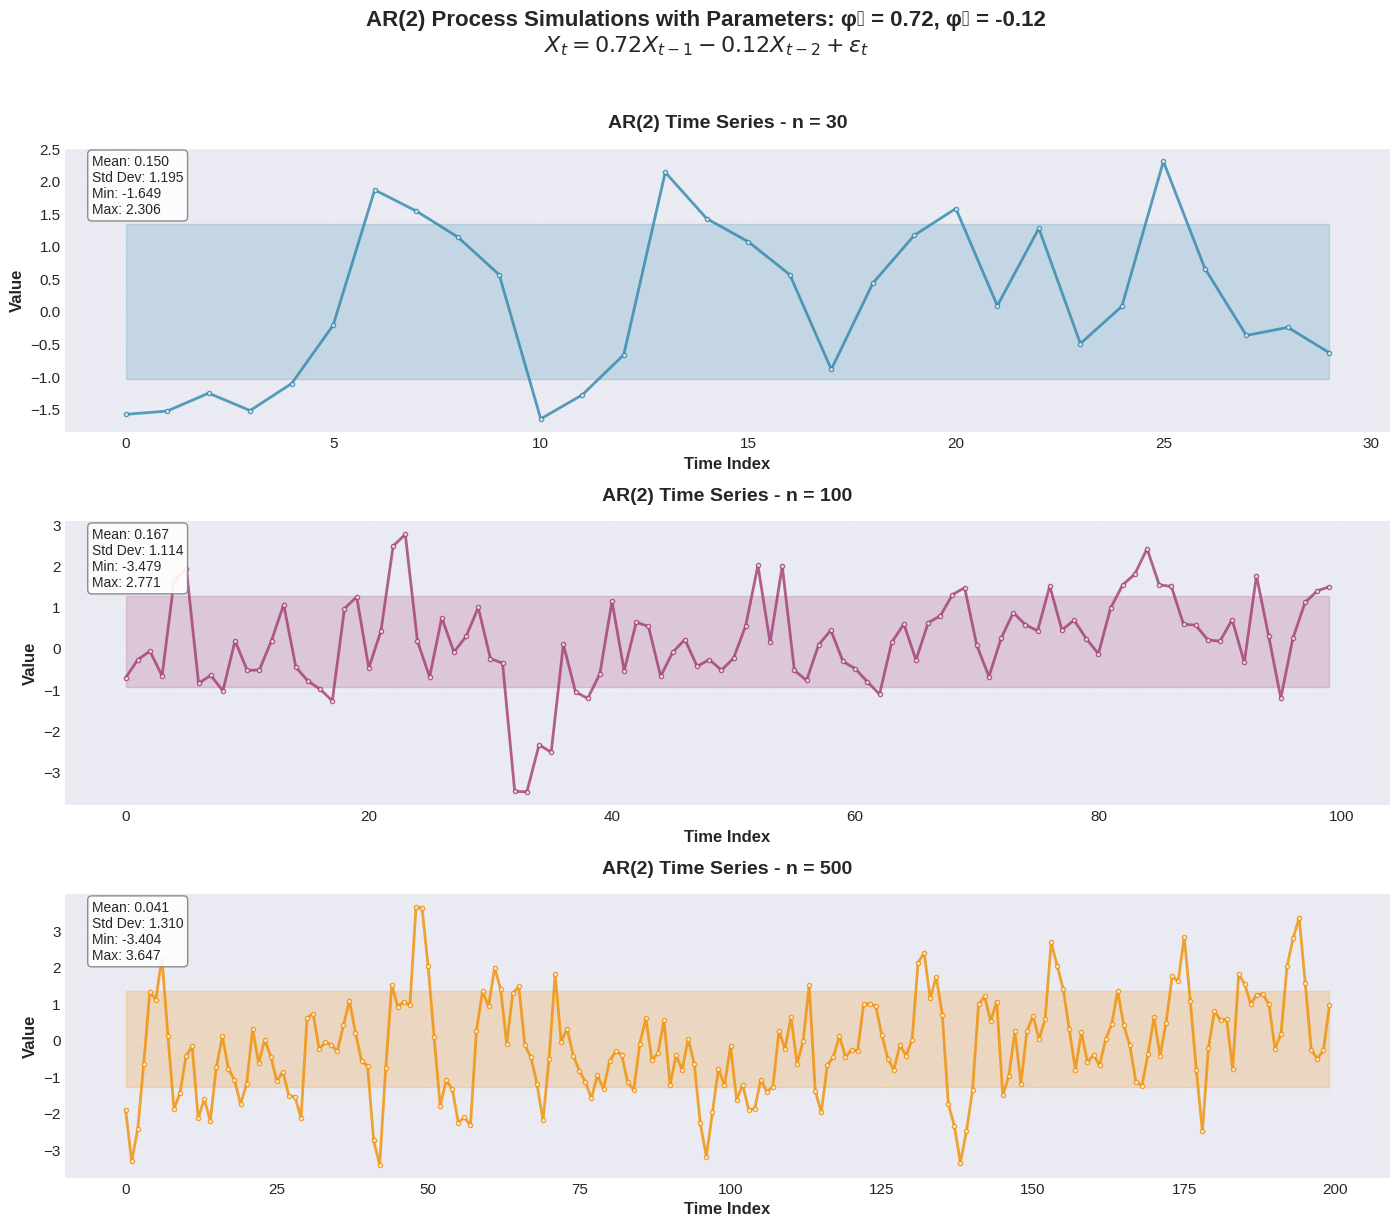

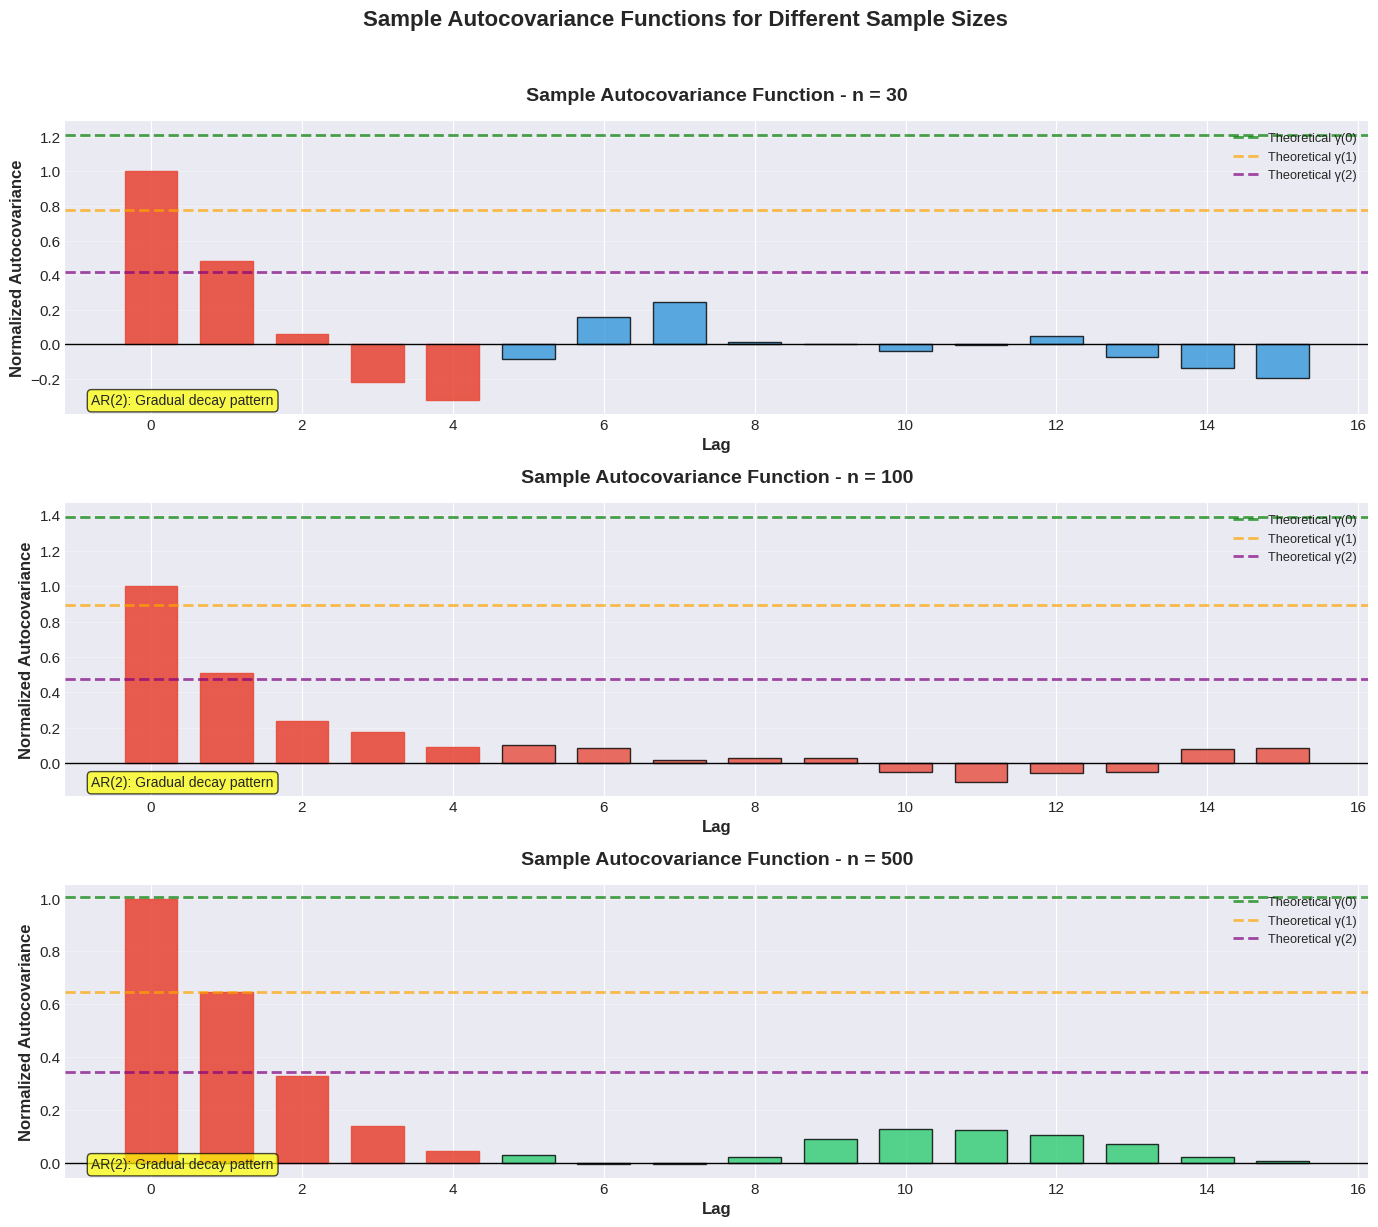

/tmp/ipython-input-1725821220.py:385: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1725821220.py:386: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Liberation Sans.
  plt.savefig('AR2_autocorrelation.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


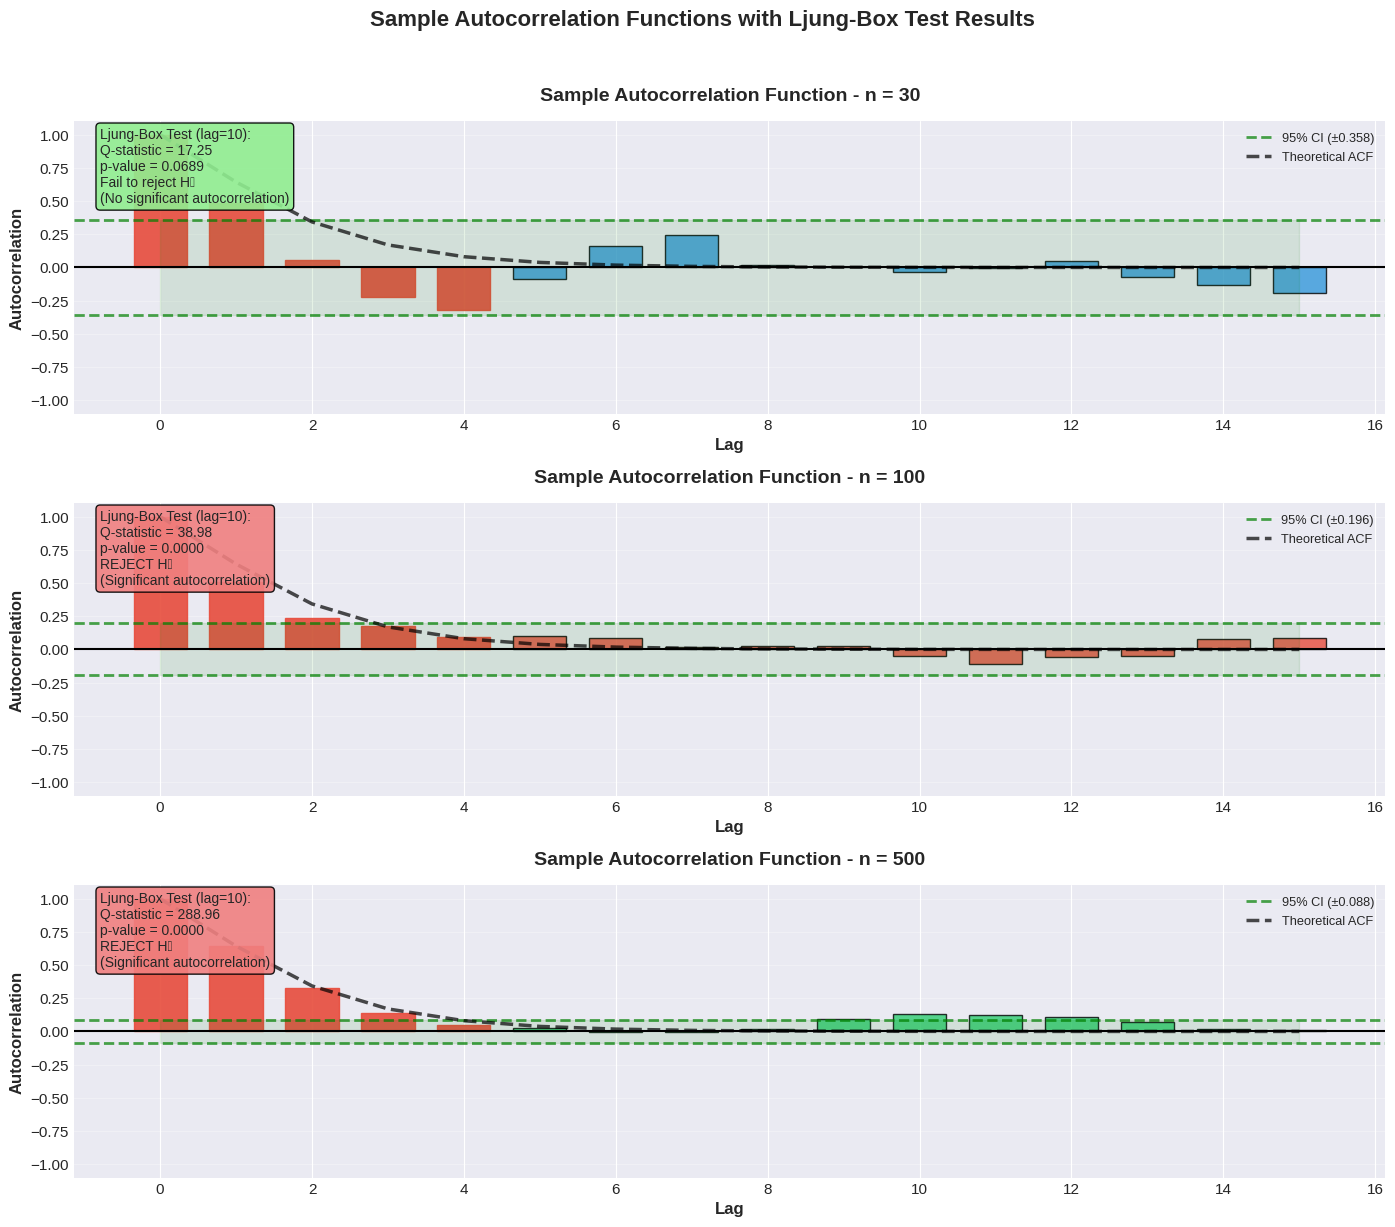

/tmp/ipython-input-1725821220.py:483: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1725821220.py:483: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1725821220.py:483: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1725821220.py:484: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Liberation Sans.
  plt.savefig('AR2_ljung_box.png', dpi=150, bbox_inches='tight')
/tmp/ipython-input-1725821220.py:484: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Liberation Sans.
  plt.savefig('AR2_ljung_box.png', dpi=150, bbox_inches='tight')
/tmp/ipython-input-1725821220.py:484: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Liberation Sans.
  plt.savefig('AR2_ljung_box.png', dpi=150, bbox_inches='tight')


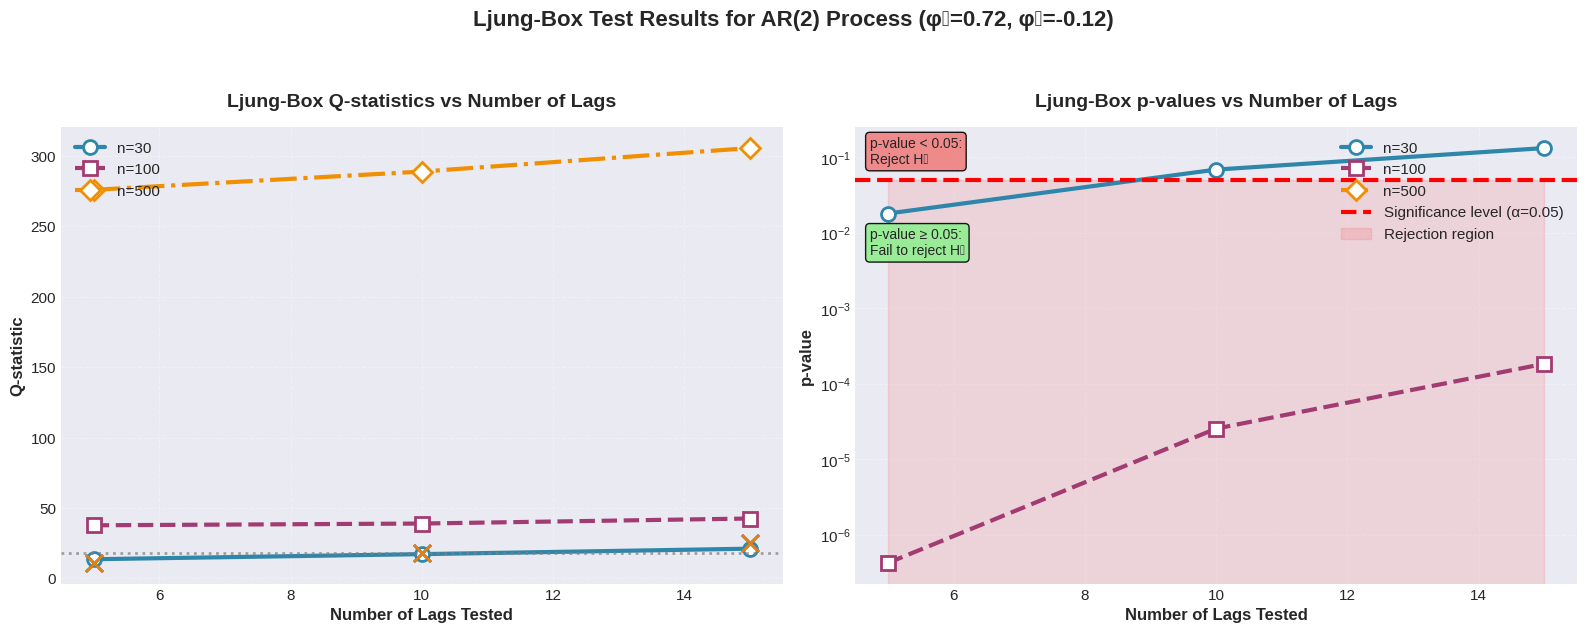


AR(2) PROCESS ANALYSIS

Parameters: φ₁ = 0.72, φ₂ = -0.12
Characteristic equation: λ² - 0.72λ - -0.12 = 0

Stationarity Conditions for AR(2):
1. φ₁ + φ₂ < 1
2. φ₂ - φ₁ < 1
3. |φ₂| < 1

Checking conditions:
  φ₁ + φ₂ = 0.72 + (-0.12) = 0.600 < 1
  φ₂ - φ₁ = -0.12 - 0.72 = -0.840 < 1
  |φ₂| = |-0.12| = 0.120 < 1

✓ All stationarity conditions are satisfied. The AR(2) process is stationary.

------------------------------------------------------------------------------------------
THEORETICAL AUTOCORRELATIONS FOR AR(2)
------------------------------------------------------------------------------------------
Theoretical ρ(1) = φ₁/(1 - φ₂) = 0.72/(1 - -0.12) = 0.6429
Theoretical ρ(2) = φ₁·ρ(1) + φ₂ = 0.72·0.6429 + -0.12 = 0.3429

Recursive calculation of ρ(k) for k > 2:
ρ(k) = φ₁·ρ(k-1) + φ₂·ρ(k-2)
  ρ(3) = 0.72·0.3429 + -0.12·0.6429 = 0.1697
  ρ(4) = 0.72·0.1697 + -0.12·0.3429 = 0.0811
  ρ(5) = 0.72·0.0811 + -0.12·0.1697 = 0.0380
  ρ(6) = 0.72·0.0380 + -0.12·0.0811 = 0.0176
  ρ(7) = 0.72

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2

# Set style for better looking charts
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Set random seed for reproducibility
np.random.seed(42)

# ============================================================================
# 1. SIMULATE AR(2) PROCESS WITH UPDATED PARAMETERS
# ============================================================================

# AR(2) parameters - CHANGED TO 0.72 AND -0.12
phi = [0.72, -0.12]  # φ1 = 0.72, φ2 = -0.12 (CHANGED)
sigma = 1.0

# Different sample sizes to analyze - CHANGED TO 30, 100, 500
sample_sizes = [30, 100, 500]  # CHANGED
max_lag = 15

# Store results
simulations = {}
acf_results = {}
acf_cov_results = {}

# Color palette for better visualization
colors = ['#2E86AB', '#A23B72', '#F18F01']
bar_colors = ['#3498db', '#e74c3c', '#2ecc71']

# Simulate for each sample size
for n in sample_sizes:
    # Generate white noise (error terms) with burn-in period
    burn_in = 100
    epsilon = np.random.normal(0, sigma, n + burn_in)

    # Generate AR(2) process: X_t = φ1*X_{t-1} + φ2*X_{t-2} + ε_t
    X = np.zeros(n + burn_in)

    # Initialize with random values
    X[0] = epsilon[0]
    X[1] = epsilon[1]

    # Generate the process
    for t in range(2, n + burn_in):
        X[t] = phi[0] * X[t-1] + phi[1] * X[t-2] + epsilon[t]

    # Discard burn-in period
    X = X[burn_in:]

    simulations[n] = X

    # Calculate sample autocorrelation function (ACF)
    mean_X = np.mean(X)
    acf_vals = []
    acf_vals_cov = []

    for k in range(max_lag + 1):
        if k == 0:
            acf_vals.append(1.0)
            acf_vals_cov.append(np.sum((X - mean_X) ** 2) / n)
        else:
            # Calculate autocovariance at lag k
            numerator = np.sum((X[k:] - mean_X) * (X[:-k] - mean_X)) / n
            denominator = np.sum((X - mean_X) ** 2) / n
            acf_vals_cov.append(numerator)
            acf_vals.append(numerator / denominator)

    acf_results[n] = acf_vals
    acf_cov_results[n] = acf_vals_cov

# ============================================================================
# 2. LJUNG-BOX TEST FUNCTION
# ============================================================================

def ljung_box_test(series, lags, alpha=0.05):
    """
    Perform Ljung-Box test for autocorrelation.

    Parameters:
    -----------
    series : array-like
        Time series data
    lags : int or list
        Number of lags to test
    alpha : float
        Significance level

    Returns:
    --------
    dict : Test statistics and results
    """
    n = len(series)

    # If lags is an integer, create list from 1 to lags
    if isinstance(lags, int):
        lags_to_test = list(range(1, lags + 1))
    else:
        lags_to_test = lags

    # Calculate sample autocorrelations
    mean_series = np.mean(series)
    autocorrs = []

    for k in lags_to_test:
        if k >= n:
            continue
        numerator = np.sum((series[k:] - mean_series) * (series[:-k] - mean_series))
        denominator = np.sum((series - mean_series) ** 2)
        autocorrs.append(numerator / denominator)

    # Calculate Ljung-Box Q statistic
    Q = n * (n + 2) * np.sum([(autocorrs[i]**2) / (n - (i + 1))
                              for i in range(len(autocorrs))])

    # Degrees of freedom = number of lags
    df = len(autocorrs)

    # Calculate p-value
    p_value = 1 - chi2.cdf(Q, df)

    # Critical value
    critical_value = chi2.ppf(1 - alpha, df)

    # Decision
    reject_h0 = p_value < alpha

    return {
        'Q_statistic': Q,
        'p_value': p_value,
        'df': df,
        'critical_value': critical_value,
        'reject_h0': reject_h0,
        'autocorrelations': autocorrs,
        'lags_tested': lags_to_test
    }

# ============================================================================
# 3. PERFORM LJUNG-BOX TESTS
# ============================================================================

# Test for different lag values
test_lags = [5, 10, 15]
ljung_box_results = {}

print("=" * 70)
print("LJUNG-BOX TEST RESULTS FOR AR(2) PROCESS")
print("=" * 70)
print(f"AR(2) Parameters: φ₁ = {phi[0]}, φ₂ = {phi[1]}")
print("=" * 70)

for n in sample_sizes:
    print(f"\nSample size: {n}")
    print("-" * 40)

    ljung_box_results[n] = {}

    for lag in test_lags:
        result = ljung_box_test(simulations[n], lag)
        ljung_box_results[n][lag] = result

        print(f"  Test up to lag {lag}:")
        print(f"    Q-statistic: {result['Q_statistic']:.4f}")
        print(f"    p-value: {result['p_value']:.6f}")
        print(f"    Critical value (α=0.05): {result['critical_value']:.4f}")

        if result['reject_h0']:
            print(f"    Decision: REJECT H₀ - Significant autocorrelation present")
        else:
            print(f"    Decision: Fail to reject H₀ - No significant autocorrelation")
        print()

# ============================================================================
# 4. PLOT TIME SERIES - UPDATED DESIGN
# ============================================================================

fig1, axes = plt.subplots(3, 1, figsize=(14, 12))
axes = axes.ravel()

for idx, n in enumerate(sample_sizes):
    # Create time series plot with enhanced styling
    time_points = np.arange(min(200, n))
    axes[idx].plot(time_points, simulations[n][:200],
                   color=colors[idx],
                   linewidth=2,
                   alpha=0.8,
                   marker='o',
                   markersize=3,
                   markerfacecolor='white',
                   markeredgecolor=colors[idx],
                   markeredgewidth=1)

    # Add shaded area for ±1 standard deviation
    std_val = np.std(simulations[n])
    mean_val = np.mean(simulations[n])
    axes[idx].fill_between(time_points,
                           mean_val - std_val,
                           mean_val + std_val,
                           color=colors[idx],
                           alpha=0.2,
                           label=f'±1 std dev')

    axes[idx].set_title(f'AR(2) Time Series - n = {n}', fontweight='bold', pad=15)
    axes[idx].set_xlabel('Time Index', fontweight='bold')
    axes[idx].set_ylabel('Value', fontweight='bold')
    axes[idx].grid(True, alpha=0.4, linestyle='--', linewidth=0.5)

    # Add statistics box
    stats_text = f'Mean: {mean_val:.3f}\nStd Dev: {std_val:.3f}\nMin: {np.min(simulations[n]):.3f}\nMax: {np.max(simulations[n]):.3f}'
    axes[idx].text(0.02, 0.98, stats_text,
                   transform=axes[idx].transAxes,
                   fontsize=10,
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

plt.suptitle(f'AR(2) Process Simulations with Parameters: φ₁ = {phi[0]}, φ₂ = {phi[1]}\n$X_t = {phi[0]}X_{{t-1}} {phi[1]:+}X_{{t-2}} + ε_t$',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('AR2_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 5. PLOT AUTOCOVARIANCE FUNCTIONS - UPDATED DESIGN
# ============================================================================

fig2, axes = plt.subplots(3, 1, figsize=(14, 12))
axes = axes.ravel()

for idx, n in enumerate(sample_sizes):
    lags = range(max_lag + 1)
    acf_vals_cov = acf_cov_results[n]

    # Normalize autocovariance for better visualization
    acf_vals_cov_normalized = np.array(acf_vals_cov) / acf_vals_cov[0] if acf_vals_cov[0] != 0 else acf_vals_cov

    # Create bar plot with enhanced styling
    bars = axes[idx].bar(lags, acf_vals_cov_normalized,
                         width=0.7,
                         alpha=0.8,
                         color=bar_colors[idx],
                         edgecolor='black',
                         linewidth=1)

    # Color the first few bars differently to highlight AR(2) structure
    for i in range(min(5, len(bars))):
        bars[i].set_color('#e74c3c')
        bars[i].set_alpha(0.9)

    axes[idx].axhline(y=0, color='black', linestyle='-', linewidth=1)

    # Calculate theoretical AR(2) autocovariance values
    # For AR(2): γ(0) = σ²/(1 - φ₁ρ₁ - φ₂ρ₂)
    # Need to solve Yule-Walker equations
    # ρ₁ = φ₁/(1 - φ₂)
    # ρ₂ = φ₁ρ₁ + φ₂

    # Calculate theoretical autocorrelations
    rho1 = phi[0] / (1 - phi[1])
    rho2 = phi[0] * rho1 + phi[1]

    # Theoretical variance
    gamma0 = sigma**2 / (1 - phi[0] * rho1 - phi[1] * rho2)

    # Theoretical autocovariances
    gamma1 = phi[0] * gamma0 + phi[1] * rho1 * gamma0
    gamma2 = phi[0] * gamma1 + phi[1] * gamma0

    # Add theoretical markers
    axes[idx].axhline(y=gamma0/acf_vals_cov[0], color='green', linestyle='--',
                     linewidth=2, alpha=0.7, label='Theoretical γ(0)')
    axes[idx].axhline(y=gamma1/acf_vals_cov[0], color='orange', linestyle='--',
                     linewidth=2, alpha=0.7, label='Theoretical γ(1)')
    axes[idx].axhline(y=gamma2/acf_vals_cov[0], color='purple', linestyle='--',
                     linewidth=2, alpha=0.7, label='Theoretical γ(2)')

    axes[idx].set_title(f'Sample Autocovariance Function - n = {n}',
                       fontweight='bold', pad=15)
    axes[idx].set_xlabel('Lag', fontweight='bold')
    axes[idx].set_ylabel('Normalized Autocovariance', fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')
    axes[idx].legend(loc='upper right', fontsize='small')

    # Add note about AR(2) gradual decay
    axes[idx].text(0.02, 0.02, 'AR(2): Gradual decay pattern',
                  transform=axes[idx].transAxes,
                  fontsize=10,
                  verticalalignment='bottom',
                  bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

plt.suptitle('Sample Autocovariance Functions for Different Sample Sizes',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('AR2_autocovariance.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 6. PLOT AUTOCORRELATION FUNCTIONS WITH LJUNG-BOX ANNOTATIONS - UPDATED DESIGN
# ============================================================================

fig3, axes = plt.subplots(3, 1, figsize=(14, 12))
axes = axes.ravel()

for idx, n in enumerate(sample_sizes):
    lags = range(max_lag + 1)
    acf_vals = acf_results[n]

    # Create bar plot with enhanced styling
    bars = axes[idx].bar(lags, acf_vals,
                         width=0.7,
                         alpha=0.8,
                         color=bar_colors[idx],
                         edgecolor='black',
                         linewidth=1)

    # Color the first few bars differently to highlight AR(2) structure
    for i in range(min(5, len(bars))):
        bars[i].set_color('#e74c3c')
        bars[i].set_alpha(0.9)

    axes[idx].axhline(y=0, color='black', linestyle='-', linewidth=1.5)

    # Add confidence intervals (95% for white noise)
    conf_level = 1.96 / np.sqrt(n)
    axes[idx].axhline(y=conf_level, color='green', linestyle='--',
                     linewidth=2, alpha=0.7, label=f'95% CI (±{conf_level:.3f})')
    axes[idx].axhline(y=-conf_level, color='green', linestyle='--',
                     linewidth=2, alpha=0.7)

    # Fill confidence interval area
    axes[idx].fill_between([0, max_lag], -conf_level, conf_level,
                           color='green', alpha=0.1)

    # Add Ljung-Box test results annotation
    lb_result = ljung_box_results[n][10]  # Using lag 10 for annotation

    # Determine color based on rejection
    box_color = 'lightcoral' if lb_result['reject_h0'] else 'lightgreen'

    p_val_text = f"Ljung-Box Test (lag=10):\n"
    p_val_text += f"Q-statistic = {lb_result['Q_statistic']:.2f}\n"
    p_val_text += f"p-value = {lb_result['p_value']:.4f}\n"

    if lb_result['reject_h0']:
        p_val_text += "REJECT H₀\n(Significant autocorrelation)"
    else:
        p_val_text += "Fail to reject H₀\n(No significant autocorrelation)"

    axes[idx].text(0.02, 0.98, p_val_text, transform=axes[idx].transAxes,
                  fontsize=10,
                  verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor=box_color,
                           alpha=0.9, edgecolor='black'))

    # Calculate theoretical AR(2) autocorrelations
    # Solve Yule-Walker equations for AR(2)
    rho1 = phi[0] / (1 - phi[1])
    rho2 = phi[0] * rho1 + phi[1]

    # Calculate theoretical ACF values recursively
    theoretical_acf = [1.0, rho1, rho2]
    for k in range(3, max_lag + 1):
        rho_k = phi[0] * theoretical_acf[k-1] + phi[1] * theoretical_acf[k-2]
        theoretical_acf.append(rho_k)

    # Plot theoretical ACF as a line
    axes[idx].plot(lags, theoretical_acf, 'k--', linewidth=2.5,
                  alpha=0.7, label='Theoretical ACF')

    axes[idx].set_title(f'Sample Autocorrelation Function - n = {n}',
                       fontweight='bold', pad=15)
    axes[idx].set_xlabel('Lag', fontweight='bold')
    axes[idx].set_ylabel('Autocorrelation', fontweight='bold')
    axes[idx].set_ylim([-1.1, 1.1])
    axes[idx].legend(loc='upper right', fontsize='small')
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.suptitle('Sample Autocorrelation Functions with Ljung-Box Test Results',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('AR2_autocorrelation.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 7. PLOT LJUNG-BOX TEST STATISTICS - UPDATED DESIGN
# ============================================================================

fig4, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Custom markers and line styles
markers = ['o', 's', 'D', '^']
line_styles = ['-', '--', '-.', ':']
colors = ['#2E86AB', '#A23B72', '#F18F01']

# Plot Q-statistics for different sample sizes and lags
for idx, n in enumerate(sample_sizes):
    q_stats = []
    for lag in test_lags:
        q_stats.append(ljung_box_results[n][lag]['Q_statistic'])

    ax1.plot(test_lags, q_stats,
             marker=markers[idx],
             color=colors[idx],
             linewidth=3,
             markersize=10,
             linestyle=line_styles[idx],
             markerfacecolor='white',
             markeredgewidth=2,
             label=f'n={n}')

    # Add critical value lines for each lag
    for lag_idx, lag in enumerate(test_lags):
        crit_val = ljung_box_results[n][lag]['critical_value']
        ax1.scatter(lag, crit_val,
                   color=colors[idx],
                   marker='x',
                   s=150,
                   alpha=0.8,
                   linewidths=2,
                   zorder=5)

ax1.set_xlabel('Number of Lags Tested', fontweight='bold', fontsize=12)
ax1.set_ylabel('Q-statistic', fontweight='bold', fontsize=12)
ax1.set_title('Ljung-Box Q-statistics vs Number of Lags',
             fontweight='bold', fontsize=14, pad=15)
ax1.legend(loc='upper left', fontsize=11)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.axhline(y=chi2.ppf(0.95, df=10), color='gray', linestyle=':',
           alpha=0.7, linewidth=2, label='χ²(10) crit (α=0.05)')

# Plot p-values with enhanced styling
for idx, n in enumerate(sample_sizes):
    p_vals = []
    for lag in test_lags:
        p_vals.append(ljung_box_results[n][lag]['p_value'])

    ax2.plot(test_lags, p_vals,
             marker=markers[idx],
             color=colors[idx],
             linewidth=3,
             markersize=10,
             linestyle=line_styles[idx],
             markerfacecolor='white',
             markeredgewidth=2,
             label=f'n={n}')

# Add significance level line and shaded area
ax2.axhline(y=0.05, color='red', linestyle='--', linewidth=3,
           label='Significance level (α=0.05)')
ax2.fill_between(test_lags, 0, 0.05,
                color='red', alpha=0.1, label='Rejection region')

ax2.set_xlabel('Number of Lags Tested', fontweight='bold', fontsize=12)
ax2.set_ylabel('p-value', fontweight='bold', fontsize=12)
ax2.set_title('Ljung-Box p-values vs Number of Lags',
             fontweight='bold', fontsize=14, pad=15)
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_yscale('log')  # Log scale for better visualization of small p-values

# Add annotations for interpretation
ax2.text(0.02, 0.98, 'p-value < 0.05:\nReject H₀',
        transform=ax2.transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightcoral',
                 alpha=0.9, edgecolor='black'))

ax2.text(0.02, 0.78, 'p-value ≥ 0.05:\nFail to reject H₀',
        transform=ax2.transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen',
                 alpha=0.9, edgecolor='black'))

plt.suptitle(f'Ljung-Box Test Results for AR(2) Process (φ₁={phi[0]}, φ₂={phi[1]})',
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('AR2_ljung_box.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# 8. ADDITIONAL ANALYSIS: STATIONARITY CHECK FOR AR(2)
# ============================================================================

print("\n" + "=" * 90)
print("AR(2) PROCESS ANALYSIS")
print("=" * 90)
print(f"\nParameters: φ₁ = {phi[0]}, φ₂ = {phi[1]}")
print(f"Characteristic equation: λ² - {phi[0]}λ - {phi[1]} = 0")

# Check stationarity conditions for AR(2)
print("\nStationarity Conditions for AR(2):")
print("1. φ₁ + φ₂ < 1")
print("2. φ₂ - φ₁ < 1")
print("3. |φ₂| < 1")

condition1 = phi[0] + phi[1]
condition2 = phi[1] - phi[0]
condition3 = abs(phi[1])

print(f"\nChecking conditions:")
print(f"  φ₁ + φ₂ = {phi[0]} + ({phi[1]}) = {condition1:.3f} {'< 1' if condition1 < 1 else '≥ 1 (VIOLATED)'}")
print(f"  φ₂ - φ₁ = {phi[1]} - {phi[0]} = {condition2:.3f} {'< 1' if condition2 < 1 else '≥ 1 (VIOLATED)'}")
print(f"  |φ₂| = |{phi[1]}| = {condition3:.3f} {'< 1' if condition3 < 1 else '≥ 1 (VIOLATED)'}")

if condition1 < 1 and condition2 < 1 and condition3 < 1:
    print("\n✓ All stationarity conditions are satisfied. The AR(2) process is stationary.")
else:
    print("\n✗ Some stationarity conditions are violated. The AR(2) process may be non-stationary.")

# Calculate theoretical autocorrelations
print("\n" + "-" * 90)
print("THEORETICAL AUTOCORRELATIONS FOR AR(2)")
print("-" * 90)

# Solve Yule-Walker equations for AR(2)
rho1 = phi[0] / (1 - phi[1])
rho2 = phi[0] * rho1 + phi[1]

print(f"Theoretical ρ(1) = φ₁/(1 - φ₂) = {phi[0]}/(1 - {phi[1]}) = {rho1:.4f}")
print(f"Theoretical ρ(2) = φ₁·ρ(1) + φ₂ = {phi[0]}·{rho1:.4f} + {phi[1]} = {rho2:.4f}")

# Calculate recursive ACF values
print("\nRecursive calculation of ρ(k) for k > 2:")
print("ρ(k) = φ₁·ρ(k-1) + φ₂·ρ(k-2)")

theoretical_acf = [1.0, rho1, rho2]
for k in range(3, 8):  # Show first 7 values
    rho_k = phi[0] * theoretical_acf[k-1] + phi[1] * theoretical_acf[k-2]
    theoretical_acf.append(rho_k)
    print(f"  ρ({k}) = {phi[0]}·{theoretical_acf[k-1]:.4f} + {phi[1]}·{theoretical_acf[k-2]:.4f} = {rho_k:.4f}")

# ============================================================================
# 9. COMPREHENSIVE SUMMARY TABLE
# ============================================================================

print("\n" + "=" * 90)
print("COMPREHENSIVE SUMMARY OF LJUNG-BOX TEST RESULTS")
print("=" * 90)
print(f"\nAR(2) Process Parameters: φ₁ = {phi[0]}, φ₂ = {phi[1]}")
print("Process: X_t = φ₁X_{t-1} + φ₂X_{t-2} + ε_t")
print("\nHypothesis Test:")
print("H₀: No autocorrelation in the residuals (white noise)")
print("H₁: Autocorrelation present in the residuals")
print("\nSignificance level: α = 0.05")
print("\n" + "-" * 90)

# Create a formatted table
print(f"{'Sample Size':<12} {'Lags':<8} {'Q-statistic':<14} {'p-value':<14} {'Critical Value':<16} {'Decision':<25}")
print("-" * 90)

for n in sample_sizes:
    for lag in test_lags:
        result = ljung_box_results[n][lag]
        decision = "REJECT H₀" if result['reject_h0'] else "Fail to reject H₀"
        decision_color = "\033[91m" if result['reject_h0'] else "\033[92m"  # Red or green
        reset_color = "\033[0m"

        print(f"{n:<12} {lag:<8} {result['Q_statistic']:<14.4f} "
              f"{result['p_value']:<14.6f} {result['critical_value']:<16.4f} "
              f"{decision_color}{decision:<25}{reset_color}")

print("\n" + "=" * 90)
print("INTERPRETATION AND ANALYSIS:")
print("=" * 90)
print(f"\nFor AR(2) process with φ = [{phi[0]}, {phi[1]}]:")
print("-" * 50)
print("1. Theoretical ACF Properties:")
print(f"   • ρ(1) = φ₁/(1 - φ₂) = {rho1:.4f}")
print(f"   • ρ(2) = φ₁·ρ(1) + φ₂ = {rho2:.4f}")
print("   • ρ(k) decays gradually (geometrically)")
print("\n2. Expected Test Results:")
print("   • AR(2) processes have significant autocorrelation at all lags")
print("   • Ljung-Box test should reject H₀ for all sample sizes")
print("   • Test power increases with sample size")
print("\n3. Ljung-Box Test Interpretation:")
print("   • Tests if ANY autocorrelation exists up to specified lag")
print("   • For AR(2), we expect to reject H₀ at all reasonable lags")
print("   • Failure to reject H₀ with small n indicates low test power")
print("\n4. Visual Indicators:")
print("   • Black dashed line shows theoretical ACF decay pattern")
print("   • Red bars highlight significant autocorrelation")
print("   • Green confidence bands show 95% interval for white noise")
print("   • Note: AR(2) ACF shows gradual decay, not abrupt cutoff")